# PoD_esti v02 —— 探测概率（Probability of Detection）估计

> **本文件从 `lidar_histogram_sim_v45.ipynb` 提取 SPAD 与二值采样内核，回答一个工程问题：**
>
> **给定环境噪声强度 → 保证噪点率 < 100 ppm / 10 ppm 的检测阈值是多少 → 该阈值下 PoD 达 50% / 90% 需要多少回波能量。**

## 缩写（首次出现给英文全称）

- **SPAD**（Single-Photon Avalanche Diode，单光子雪崩二极管）
- **PDE**（Photon Detection Efficiency，光子探测效率）
- **ToF**（Time of Flight，飞行时间）
- **IRF**（Instrument Response Function，仪器响应函数）
- **HDC**（Hardware Data Channel，硬件数据通道）：执行「1 ns 时钟采样 → 比 60% 阈值 → 出 0/1」的采样单元
- **Vov**（Over Voltage，过电压）= V_bias − V_br
- **FAR**（False Alarm Rate，虚警率 / 噪点率）
- **PoD**（Probability of Detection，探测概率）
- **MC**（Monte Carlo，蒙特卡洛）
- **ppm**（parts per million，百万分之一）：100 ppm = 1e-4，10 ppm = 1e-5

## 三步流程

| 步骤 | 做什么 | 输出 | 模块 |
|---|---|---|---|
| **第 1 步** | 关掉信号，扫不同强度的环境噪声；每档采多条 0–200 ns 波形，**掐头去尾各 24 ns**；每条记 `noise`（统计窗内各 bin 计数均值）与 `peak`（统计窗内最大 bin 计数） | **noise–peak 曲线** | 5 |
| **第 2 步** | 对每个噪声档反解最小整数阈值 `T`，使 **P(peak ≥ T) < 100 ppm**，以及 **< 10 ppm** | **noise–threshold 曲线（两条）** | 6 |
| **第 3 步** | 以「峰值 ≈ noise + 3σ」为起点扫信号能量，每档 MC 出 peak 分布，用第 2 步的 `T` 判定 | **PoD–能量曲线**，反解 **E@PoD50 / E@PoD90** | 7–8 |

---

## v02 相对 v01（`PoD_esti.ipynb`）改了什么

**物理参数一律未改。** 只改了"怎么扫、扫多密、怎么画"。

| 项 | v01 | **v02（本文件）** | 为什么 |
|---|---|---|---|
| 噪声档的自变量 | `E_lambda` 的**对数**倍数 `[0.01, 0.03, 0.1, 0.3, 1, 3, 10]`，共 7 档 | **目标 `noise` 线性等间距**，每个 N_shots **40 档**；再反解所需的 `E_lambda` | 用户要求"每一个 noise（如 9 和 10）都有足够样本点" |
| 模块 5/6 坐标轴 | 对数 | **线性** | 用户要求 |
| 每档 MC 条数 | 1e6 | **1e6**（不变，但档数从 7 → 40） | 10 ppm 需要 ≥1e6 才有约 10 个越阈事件 |
| 噪点率阈值 | 只有 100 ppm | **100 ppm 与 10 ppm 两条** | 用户要求 |
| 快速引擎 A | `np.interp` 二分查表（O(log N)） | **均匀 E 网格反函数直查表（O(1)）+ float32** | 档数涨了 6 倍，必须提速；实测 **2.5×** |
| MC 结果缓存 | 存全部 peak 原始样本 | **只存 peak 的 bincount** | 40 档 × 1e6 的原始样本要 320 MB；bincount 只有 ~110 个整数，且信息无损 |

### 关键新增：用更新过程平衡态公式反解 `noise → E_lambda`

要把噪声档摆在**线性等间距的 noise 上**，就必须知道"想要 noise = 9.0，环境光该开多大"。

朴素做法是用 $\mathrm{noise} = n_\mathrm{tr}\left[1-e^{-r_\mathrm{det}T_\mathrm{OVER}}\right]$ 反解，
但这条式子把雪崩当成速率 $r_\mathrm{det}$ 的 Poisson 过程，**忽略了 RC 恢复带来的 8 ns 计数死区**，
在高噪声端会偏 6% 以上（见模块 3d 的实测对照）。

正确做法用**更新过程（renewal process）的平衡态**：某采样点被点亮 ⟺ 它的**回溯时间**
（backward recurrence time，距上一次雪崩多久）小于 $T_\mathrm{OVER}$。平衡态下回溯时间的密度是
$f_B(u)=S(u)/\mu$，其中 $S(u)=e^{-H(u)}$ 是等待时间的生存函数、$\mu=\int_0^\infty S$ 是平均雪崩间隔，于是

$$p_\mathrm{bin} = \frac{1}{\mu}\int_0^{T_\mathrm{OVER}} S(u)\,\mathrm{d}u,
\qquad \mathrm{noise} = n_\mathrm{tr}\cdot p_\mathrm{bin}$$

Poisson 是它的特例（$S=e^{-ru}$ 时退化为 $1-e^{-rT_\mathrm{OVER}}$）。
**实测反解精度优于 0.12%**（模块 3d）。


## 模块 0 — 参数与常数

物理参数整段沿用 `lidar_histogram_sim_v45.ipynb` cell 3（与 `PoD_esti.ipynb` v01 完全一致）；
末尾是 `PoD_esti` 专用参数区，v02 改动的项已标 ★。


In [1]:
import json, os, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import binom as _binom

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

C_LIGHT  = 2.99792458e8      # 光速 [m/s]
H_PLANCK = 6.62607015e-34    # 普朗克常数 [J·s]

# ============================ 物理参数（与 v45 / v01 逐项一致，未改） ============================
PARAMS = {
    "laser": {
        "wavelength": 905e-9,   # 波长 [m]
        "amp_mode": "peak",     # "peak"=用 P_peak 定幅 / "energy"=用 E_pulse 定幅
        "P_peak": 235.0,        # 峰值光功率 [W]
        "E_pulse": 800e-9,      # 目标单脉冲能量 [J]（amp_mode="energy" 时生效）
        "tau_r": 0.7e-9,        # 双指数上升时间常数 [s]
        "tau_f": 1.9e-9,        # 双指数下降时间常数 [s]
        "x_L": 60e-6,           # 发光面 X 尺寸（慢轴, 1/e² 全宽）[m]
        "y_L": 1150e-6,         # 发光面 Y 尺寸（快轴, 1/e² 全宽）[m]
    },
    "tx": {"f_TX": 36e-3, "D_TX": 12.7e-3, "eta_coupling": 0.87, "T_TX": 0.92},
    "channel": {"alpha": 0.1e-3},          # 消光系数 @905 nm [1/m]（0.1/km ≈ 晴朗）
    "rx": {"f_RX": 25e-3, "D_RX": 13e-3, "eta_RX": 0.82,
           "T_RX": 0.90, "T_filter": 0.90, "filter_bw": 12e-9},
    "spad": {
        "PDE": 0.30,            # PDE_max，满过电压时的峰值光子探测效率
        "DCR": 0.0e3,           # 单像元暗计数率 [cps]
        "jitter_sigma": 100e-12,# IRF 高斯 σ [s]
        "tau_rc": 8.7315e-9,    # RC 恢复时间常数 τ = R·C_J [s]（使计数死区 = 8 ns）
        "Vov_max": 3.3,         # 满过电压 [V]
        "Vth_frac": 0.60,       # 计数所需最小过电压占比
        "reset_mode": "count",
        "resp_shape": "exp",    # 响应函数 g(Vov) 形状
        "resp_k": 3.0,
    },
    "spad_array": {"pitch": 10e-6, "Nx": 9, "Ny": 120, "fill_factor": 1.00},
    "ambient": {
        "enable": True,
        "E_lambda": 0.68,       # 905 nm 处光谱辐照度 [W/m²/nm]，≈100 klux 白天（基准值）
        "surface_rho": 0.10,    # 被观测面反射率（用于环境光漫反射）
    },
    "hist": {"bin_width": 1e-9, "seed": 0},
}
E_PHOTON = H_PLANCK * C_LIGHT / PARAMS["laser"]["wavelength"]

# ============================ PoD_esti 专用参数区（可调） ============================
# ---- 场景 ----
D_TARGET   = 15.0        # 目标距离 [m] → ToF ≈ 100.07 ns，落在 0–200 ns 窗正中
RHO_TARGET = 0.10        # 目标反射率（与 v45 主回波一致）

# ---- 采集窗与统计窗 ----
WIN_LO_NS  = 0.0         # 采集窗起点 [ns]
WIN_HI_NS  = 200.0       # 采集窗终点 [ns]
TRIM_NS    = 24.0        # 掐头去尾各多少 ns（= 3 × 过阈窗宽 8 ns），统计时剔除
WARM_NS    = 50.0        # 光子生成的左侧护带（暖机）[ns]，采样点不动
DT_FINE    = 200e-12     # 逐光子引擎的细网格步长 [s]（同 v45）

# ---- 宏像元（macro pixel）----
MACRO_BX   = 9           # 沿短边 x 的 SPAD 数
MACRO_BY   = 3           # 沿长边 y 的 SPAD 数   ⇒ 27 个 SPAD
N_SHOTS_LIST = [1, 4]    # 两种累加发数都做

# ---- ★ v02：第 1、2 步的噪声档，改为【目标 noise 线性等间距】 ----
#   键 = N_shots；值 = 目标底噪（宏像元每 1 ns bin 的平均计数）。
#   两条网格都覆盖到各自二值硬上限（27 / 108）的约 20%，并都包含 noise = 9 与 10。
NOISE_GRID = {
    1: np.round(np.arange(0.25, 10.0 + 1e-9, 0.25), 4),   # 40 档，上限 27
    4: np.round(np.arange(0.50, 20.0 + 1e-9, 0.50), 4),   # 40 档，上限 108
}
TARGET_FARS = [100e-6, 10e-6]   # ★ v02：同时给 100 ppm 与 10 ppm 两条阈值
N_MC_NOISE  = 1_000_000         # 每档纯噪声 MC 条数（10 ppm 需 ≥1e6 才有约 10 个越阈事件）
# 分块大小：快速引擎 A 峰值内存 ≈ chunk × n_tr × 4 B × 约 8 个中间数组。
# chunk=100_000 会到 GB 级并因内存压力显著掉速；25_000 约 150 MB，实测最快。
MC_CHUNK    = 25_000

# ---- 第 3 步：能量扫描与 PoD ----
#   ★ v02：PoD 的环境档直接按【目标 noise】指定（两种 N_shots 用同一组 noise，便于公平对比）
NOISE_POD  = [1.0, 5.0, 10.0]
N_MC_POD   = 3000        # 每个能量档的 MC 条数（PoD≈0.5 时精度 ±0.9%）
N_E_GRID   = 24          # 能量档数（对数网格）
SIG_PRE_NS = 3.0         # 信号窗：ToF 之前 [ns]
SIG_POST_NS= 12.0        # 信号窗：ToF 之后 [ns]（覆盖 8 ns 过阈窗 + 余量）
POD_WARM_NS= 60.0        # PoD 子窗的暖机长度 [ns]（≫ 3τ_RC + T_OVER ≈ 34 ns）

# ---- 缓存 ----
USE_CACHE   = True
CACHE_NOISE = "pod_esti_v02_cache_noise.npz"
CACHE_POD   = "pod_esti_v02_cache_pod.npz"

print(f"单光子能量 E_photon = {E_PHOTON:.3e} J")
print(f"目标 D = {D_TARGET} m → ToF = {2*D_TARGET/C_LIGHT*1e9:.2f} ns")
print(f"采集窗 {WIN_LO_NS:.0f}–{WIN_HI_NS:.0f} ns，bin 宽 {PARAMS['hist']['bin_width']*1e9:.0f} ns，"
      f"掐头去尾各 {TRIM_NS:.0f} ns")
print(f"宏像元 {MACRO_BX}×{MACRO_BY} = {MACRO_BX*MACRO_BY} 个 SPAD；N_shots 取 {N_SHOTS_LIST}")
for _ns, _g in NOISE_GRID.items():
    print(f"  ★ N_shots={_ns} 的噪声网格：noise = {_g[0]:g} → {_g[-1]:g}，"
          f"步长 {_g[1]-_g[0]:g}，共 {_g.size} 档（线性等间距）")
print(f"  ★ 噪点率目标：{[f'{f*1e6:.0f} ppm' for f in TARGET_FARS]}，每档 {N_MC_NOISE:,} 次 MC")


单光子能量 E_photon = 2.195e-19 J
目标 D = 15.0 m → ToF = 100.07 ns
采集窗 0–200 ns，bin 宽 1 ns，掐头去尾各 24 ns
宏像元 9×3 = 27 个 SPAD；N_shots 取 [1, 4]
  ★ N_shots=1 的噪声网格：noise = 0.25 → 10，步长 0.25，共 40 档（线性等间距）
  ★ N_shots=4 的噪声网格：noise = 0.5 → 20，步长 0.5，共 40 档（线性等间距）
  ★ 噪点率目标：['100 ppm', '10 ppm']，每档 1,000,000 次 MC


## 模块 1 — 光链路（从 v45 cell 5/7/9/11/13/15 移植，函数逐行一致）

这一段只负责回答「一个 SPAD 每秒收到多少个信号光子、多少个环境光子」，**都不含 PDE**：

- 信号：激光双指数脉冲 → 发射光学 → 往返大气 `exp(−2αD)` → 朗伯目标 `ρ/π` → 接收立体角 `A_RX/D²`
  → 像面椭圆高斯光斑 → 各 SPAD 的空间收集比例 `f_pix`；
- 环境光：带内辐照 `E_λ·Δλ` → 辐亮度 `ρ·E/π` → 单像元 `L·iFOV²·A_RX` → 光子率。

环境光速率**与像元位置无关**（每个 SPAD 都一样），所以第 1、2 步完全用不到 `f_pix`。
`E_lambda = 0.68 W/m²/nm` 就是基准环境光档（≈100 klux 白天）；v02 会反过来求"要多大的
`E_lambda` 才能得到指定的 noise"。


In [2]:
# ---- 激光脉冲 ----
def _pulse_norm(p=PARAMS):
    tr, tf_ = p["laser"]["tau_r"], p["laser"]["tau_f"]
    t_peak = np.log(tf_ / tr) / (1.0 / tr - 1.0 / tf_)
    s_peak = np.exp(-t_peak / tf_) - np.exp(-t_peak / tr)
    area_shape = tf_ - tr
    A = (p["laser"]["E_pulse"] * s_peak / area_shape
         if p["laser"]["amp_mode"] == "energy" else p["laser"]["P_peak"])
    return A, s_peak, t_peak, area_shape

def pulse_temporal(t, p=PARAMS):
    """激光时域光功率 P(t) [W]（双指数）。"""
    tr, tf_ = p["laser"]["tau_r"], p["laser"]["tau_f"]
    A, s_peak, _, _ = _pulse_norm(p)
    tpos = np.clip(t, 0.0, None)
    shape = np.where(t >= 0, np.exp(-tpos / tf_) - np.exp(-tpos / tr), 0.0)
    return A * np.clip(shape, 0.0, None) / s_peak

def pulse_energy(p=PARAMS):
    """单脉冲发射能量 [J] = ∫P(t)dt（双指数解析值 = A/s_peak·(τ_f−τ_r)）。"""
    A, s_peak, _, area_shape = _pulse_norm(p)
    return A / s_peak * area_shape

# ---- 发射光学 / 信道 / 目标 ----
def tx_derived(p=PARAMS):
    x_L, y_L = p["laser"]["x_L"], p["laser"]["y_L"]
    f_TX = p["tx"]["f_TX"]; lam = p["laser"]["wavelength"]; w0 = p["tx"]["D_TX"] / 2.0
    tgx, tgy = x_L / (2 * f_TX), y_L / (2 * f_TX)
    tdf = lam / (np.pi * w0)
    tx_, ty_ = np.hypot(tgx, tdf), np.hypot(tgy, tdf)
    return {"theta_x": tx_, "theta_y": ty_, "zR_x": w0 / tx_, "zR_y": w0 / ty_, "w0": w0,
            "eta_TX": p["tx"]["eta_coupling"] * p["tx"]["T_TX"]}

def atm_transmission(D, p=PARAMS):
    return np.exp(-p["channel"]["alpha"] * D)

def beam_spot_size(D, p=PARAMS):
    tx = tx_derived(p); w0 = tx["w0"]
    return (2 * w0 * np.sqrt(1 + (D / tx["zR_x"])**2),
            2 * w0 * np.sqrt(1 + (D / tx["zR_y"])**2))

def time_of_flight(D):
    return 2.0 * D / C_LIGHT

def lambertian_brdf(rho):
    return rho / np.pi

def echo_range_broadening_sigma(D, tilt_deg, p=PARAMS):
    """目标倾斜带来的几何测距展宽 σ [s]（本文件 tilt=0，返回 0）。"""
    x_D, y_D = beam_spot_size(D, p)
    w = 0.5 * np.hypot(x_D, y_D) / np.sqrt(2)
    dz = w * np.tan(np.deg2rad(tilt_deg))
    return (2.0 * dz / C_LIGHT) / 2.0

# ---- 接收光学 ----
def rx_area(p=PARAMS):
    return np.pi * (p["rx"]["D_RX"] / 2.0)**2

def airy_diameter(p=PARAMS):
    fnum = p["rx"]["f_RX"] / p["rx"]["D_RX"]
    return 2.44 * p["laser"]["wavelength"] * fnum

def rx_image_spot_size(D, p=PARAMS):
    """RX 像面光斑 1/e² 全宽 [m] = 几何成像 ⊕ 衍射艾里斑（平方和）。"""
    x_D, y_D = beam_spot_size(D, p)
    s_airy = airy_diameter(p)
    return (np.hypot((x_D / D) * p["rx"]["f_RX"], s_airy),
            np.hypot((y_D / D) * p["rx"]["f_RX"], s_airy))

def link_factor(echo, p=PARAMS):
    """从发射光功率到单位收集比例下接收光功率的总链路因子（无量纲）。"""
    tx = tx_derived(p); D = echo["D"]
    Omega = rx_area(p) / D**2
    eta_rx_total = p["rx"]["eta_RX"] * p["rx"]["T_RX"] * p["rx"]["T_filter"]
    return (tx["eta_TX"] * echo["frac"] * lambertian_brdf(echo["rho"]) * Omega
            * atm_transmission(D, p)**2 * eta_rx_total)

# ---- 像元收集比例 & 环境光 ----
def gaussian_kernel(sigma, dt, n_sigma=5):
    if sigma <= 0:
        return np.array([1.0 / dt])
    half = max(1, int(np.ceil(n_sigma * sigma / dt)))
    tk = np.arange(-half, half + 1) * dt
    k = np.exp(-0.5 * (tk / sigma)**2)
    return k / (k.sum() * dt)

def pixel_grid(p=PARAMS):
    a = p["spad_array"]; pitch = a["pitch"]
    xi = (np.arange(a["Nx"]) - (a["Nx"] - 1) / 2.0) * pitch
    yj = (np.arange(a["Ny"]) - (a["Ny"] - 1) / 2.0) * pitch
    return xi, yj

def pixel_collection_matrix(D, p=PARAMS):
    """每个像元在椭圆高斯像斑上的空间收集比例 f_pix[i,j]（∑ ≤ 1，其余漏到阵列外）。"""
    sx, sy = rx_image_spot_size(D, p)
    sig_x, sig_y = sx / 4.0, sy / 4.0
    xi, yj = pixel_grid(p); pitch = p["spad_array"]["pitch"]
    def _frac(centers_, sig):
        lo = (centers_ - pitch / 2.0) / (np.sqrt(2) * sig)
        hi = (centers_ + pitch / 2.0) / (np.sqrt(2) * sig)
        return 0.5 * (erf(hi) - erf(lo))
    fx = _frac(xi, sig_x); fy = _frac(yj, sig_y)
    return np.outer(fx, fy), fx, fy

def ambient_photon_rate_per_pixel(p=PARAMS, e_lambda=None):
    """单像元环境光【光子到达率】[ph/s]，不含 PDE。
    e_lambda 不给则用 PARAMS 里的基准值 0.68 W/m²/nm（≈100 klux）。"""
    if not p["ambient"]["enable"]:
        return 0.0
    E_l = p["ambient"]["E_lambda"] if e_lambda is None else e_lambda
    E = E_l * (p["rx"]["filter_bw"] * 1e9)                        # 带内辐照 [W/m²]
    L = p["ambient"]["surface_rho"] * E / np.pi                   # 辐亮度 [W/m²/sr]
    iFOV = p["spad_array"]["pitch"] / p["rx"]["f_RX"]
    P_amb = L * iFOV**2 * rx_area(p)
    return P_amb / E_PHOTON * p["rx"]["T_RX"] * p["rx"]["T_filter"]

def signal_photon_rate_fine(echo, f_pix_ij, tf_grid, p=PARAMS):
    """单 SPAD 信号【光子到达率】[ph/s]（不含 PDE），在精细网格 tf_grid 上。"""
    t0 = time_of_flight(echo["D"])
    r = (pulse_temporal(tf_grid - t0, p) * link_factor(echo, p) / E_PHOTON * f_pix_ij)
    sig_b = echo_range_broadening_sigma(echo["D"], echo.get("tilt_deg", 0.0), p)
    if sig_b > 0:
        dtf = tf_grid[1] - tf_grid[0]
        r = np.convolve(r, gaussian_kernel(sig_b, dtf), mode="same") * dtf
    return r

# ---- 自检 ----
ECHO0 = {"D": D_TARGET, "rho": RHO_TARGET, "frac": 1.00, "tilt_deg": 0.0}
E_PULSE_BASE = pulse_energy()
_sx, _sy = rx_image_spot_size(D_TARGET)
print("="*78)
print(f"单脉冲发射能量 E_pulse = {E_PULSE_BASE*1e9:.1f} nJ（P_peak={PARAMS['laser']['P_peak']:.0f} W，"
      f"双指数 τ_r={PARAMS['laser']['tau_r']*1e9:.1f} / τ_f={PARAMS['laser']['tau_f']*1e9:.1f} ns）")
print(f"D={D_TARGET} m: 像面光斑 1/e² 全宽 x={_sx*1e6:.2f} µm, y={_sy*1e6:.2f} µm")
print(f"链路因子 link_factor = {link_factor(ECHO0):.3e}（ρ={RHO_TARGET}）")
print(f"环境光基准 E_lambda = {PARAMS['ambient']['E_lambda']} W/m²/nm（≈100 klux）："
      f"单像元 r_amb = {ambient_photon_rate_per_pixel():.3e} ph/s  "
      f"→ 探测率 r_det = r_amb·PDE = {ambient_photon_rate_per_pixel()*PARAMS['spad']['PDE']:.3e} cps")


单脉冲发射能量 E_pulse = 799.4 nJ（P_peak=235 W，双指数 τ_r=0.7 / τ_f=1.9 ns）
D=15.0 m: 像面光斑 1/e² 全宽 x=46.98 µm, y=798.91 µm
链路因子 link_factor = 9.953e-09（ρ=0.1）
环境光基准 E_lambda = 0.68 W/m²/nm（≈100 klux）：单像元 r_amb = 2.036e+07 ph/s  → 探测率 r_det = r_amb·PDE = 6.107e+06 cps


## 模块 2 — 时间窗、宏像元、掐头去尾

**采集窗**：0 – 200 ns，bin 宽 1 ns ⇒ 200 个 bin，bin 中心在 0.5, 1.5, …, 199.5 ns。

**统计窗（掐头去尾）**：剔除首尾各 24 ns（= 3 × 过阈窗宽 `T_OVER` ≈ 8 ns），
保留 bin 中心落在 [24, 176] ns 的 **152 个 bin**。

为什么要掐头：二值引擎每次雪崩把输出向**右**铺一个 8 ns 的过阈窗，所以采集窗最左端的 bin
本应收到来自窗外（t < 0）上游雪崩的"尾巴"，但那些光子在仿真里根本没被生成 ⇒ 前 ~8 ns 的 bin
会系统性偏低（"最开始没噪声"的边界假象）。本文件**双保险**：
① 光子生成网格向左扩 50 ns 护带（`WARM_NS`），采样点不动；② 再掐掉 24 ns。
掐尾在物理上并非必需（未来的光子影响不了过去的 bin），保留只为对称与保险。

**过阈窗宽**（导出量，非独立参数）：

$$T_\mathrm{OVER} = -\,\tau_\mathrm{RC}\cdot\ln\!\left(1-V_\mathrm{th,frac}\right)
= -\,8.7315\ \mathrm{ns}\times\ln(1-0.60)\approx 8.00\ \mathrm{ns}$$

**二值硬上限**：单 SPAD 每 bin 每 shot ∈ {0,1} ⇒ 宏像元 27 SPAD 求和 ∈ [0,27]
⇒ 累加 N_shots 后峰 bin 硬上限 `macro_cap = 27 × N_shots`。


In [3]:
# ---- SPAD 器件参数（从 PARAMS["spad"] 解出全局量，命名沿用 v45） ----
_sp = PARAMS["spad"]
PDE        = _sp["PDE"]
JIT        = _sp["jitter_sigma"]
TAU_RC     = _sp["tau_rc"]
VTH_FRAC   = _sp["Vth_frac"]
RESP_SHAPE = _sp["resp_shape"]
RESP_K     = _sp["resp_k"]
jit = JIT

T_OVER = -TAU_RC * np.log(1.0 - VTH_FRAC)          # 过阈窗宽 ≈ 8.00 ns（导出量）

# ---- 时间窗与 bin ----
BIN_W  = PARAMS["hist"]["bin_width"]
WIN_LO, WIN_HI = WIN_LO_NS * 1e-9, WIN_HI_NS * 1e-9
NBINS  = int(round((WIN_HI - WIN_LO) / BIN_W))
CENTERS = WIN_LO + (np.arange(NBINS) + 0.5) * BIN_W        # bin 中心 [s]
TC_NS   = CENTERS * 1e9

# 统计窗（掐头去尾）：bin 中心落在 [TRIM, WIN_HI-TRIM] 内
_keep = (TC_NS >= TRIM_NS) & (TC_NS <= WIN_HI_NS - TRIM_NS)
IDX_STAT = np.where(_keep)[0]
I_STAT0, I_STAT1 = int(IDX_STAT[0]), int(IDX_STAT[-1] + 1)   # 切片 [I_STAT0, I_STAT1)
N_STAT = I_STAT1 - I_STAT0

# 光子生成网格（左扩护带，采样点不动）
TF_GEN = np.arange(WIN_LO - WARM_NS*1e-9, WIN_HI, DT_FINE)

# ---- 宏像元 ----
N_PIX_MACRO = MACRO_BX * MACRO_BY
FPIX, FX, FY = pixel_collection_matrix(D_TARGET)
_n_macro = PARAMS["spad_array"]["Ny"] // MACRO_BY
_macro_fsum = np.array([FPIX[:, m*MACRO_BY:(m+1)*MACRO_BY].sum() for m in range(_n_macro)])
M_PEAK = int(_macro_fsum.argmax())
F_VALS = FPIX[:, M_PEAK*MACRO_BY:(M_PEAK+1)*MACRO_BY].ravel()   # 峰值宏像元 27 个 SPAD 的收集比例

# ---- 环境光基准速率 ----
R_AMB_BASE = ambient_photon_rate_per_pixel()       # E_lambda = 0.68 时的单像元光子率 [ph/s]

# ---- 信号率形状（单位收集比例、boost=1）----
T0_SIG   = time_of_flight(D_TARGET)
T0_SIG_NS= T0_SIG * 1e9
R_SIG_UNIT_GEN = signal_photon_rate_fine(ECHO0, 1.0, TF_GEN)    # [ph/s]，f_pix=1

print("="*78)
print(f"过阈窗宽 T_OVER = -τ_RC·ln(1-Vth_frac) = {T_OVER*1e9:.3f} ns")
print(f"采集窗 {WIN_LO_NS:.0f}–{WIN_HI_NS:.0f} ns → {NBINS} 个 1 ns bin（中心 "
      f"{TC_NS[0]:.1f} … {TC_NS[-1]:.1f} ns）")
print(f"统计窗（掐头去尾 {TRIM_NS:.0f} ns）→ bin 下标 [{I_STAT0}, {I_STAT1}) 共 {N_STAT} 个，"
      f"中心 {TC_NS[I_STAT0]:.1f} … {TC_NS[I_STAT1-1]:.1f} ns")
print(f"生成网格 TF_GEN：{TF_GEN[0]*1e9:.1f} … {TF_GEN[-1]*1e9:.1f} ns，"
      f"步长 {DT_FINE*1e12:.0f} ps，共 {TF_GEN.size} 点（左扩护带 {WARM_NS:.0f} ns）")
print(f"宏像元 {MACRO_BX}×{MACRO_BY} = {N_PIX_MACRO} SPAD；峰值宏像元 m={M_PEAK}"
      f"（Σf_pix={_macro_fsum[M_PEAK]:.4f}）")
for ns_ in N_SHOTS_LIST:
    print(f"  N_shots={ns_} → 轨迹数 n_tr = 27×{ns_} = {N_PIX_MACRO*ns_}，"
          f"二值硬上限 macro_cap = {N_PIX_MACRO*ns_}")
print(f"信号峰位 ToF = {T0_SIG_NS:.2f} ns（bin 下标 {int(T0_SIG_NS)}）")
print(f"环境光基准 r_amb = {R_AMB_BASE:.3e} ph/s，r_det = {R_AMB_BASE*PDE:.3e} cps")


过阈窗宽 T_OVER = -τ_RC·ln(1-Vth_frac) = 8.001 ns
采集窗 0–200 ns → 200 个 1 ns bin（中心 0.5 … 199.5 ns）
统计窗（掐头去尾 24 ns）→ bin 下标 [24, 176) 共 152 个，中心 24.5 … 175.5 ns
生成网格 TF_GEN：-50.0 … 200.0 ns，步长 200 ps，共 1251 点（左扩护带 50 ns）
宏像元 9×3 = 27 SPAD；峰值宏像元 m=19（Σf_pix=0.0597）
  N_shots=1 → 轨迹数 n_tr = 27×1 = 27，二值硬上限 macro_cap = 27
  N_shots=4 → 轨迹数 n_tr = 27×4 = 108，二值硬上限 macro_cap = 108
信号峰位 ToF = 100.07 ns（bin 下标 100）
环境光基准 r_amb = 2.036e+07 ph/s，r_det = 6.107e+06 cps


## 模块 3 — SPAD 二值采样引擎

### 3a 精确引擎（`spad_binary_trace`，从 v45 cell 32 原样移植）

单 SPAD、单次 shot 的二值采样，四步机制：

1. 光子按 Poisson(r·dt) 到达细网格（信号率 + 环境率，**均不含 PDE**）；
2. 逐光子判雪崩，触发概率

$$p_\mathrm{fire} = \mathrm{PDE_{max}}\cdot g(v),\qquad
v = 1-e^{-(t-t_\mathrm{last})/\tau_\mathrm{RC}},\qquad
g(x) = \frac{1-e^{-kx}}{1-e^{-k}}\ (k=3)$$

   **二值模型下每次雪崩都把 Vov 拉回 0**；
3. 每次雪崩把输出在 $[t_\mathrm{av},\,t_\mathrm{av}+T_\mathrm{OVER}]$ 拉高为 1，多次雪崩窗口顺延堆积；
4. HDC 每 1 ns 采一次，落入任一拉高区间 → 该 bin 记 1。

### 3b 快速引擎（★ v02 进一步优化）

精确引擎是**逐光子 Python 循环**，实测约 **8 ms / 条宏像元波形**。
v02 要跑 40 档 × 2 种 N_shots × 1e6 条，非快速引擎不可。

| 引擎 | 适用 | 原理 | 提速 |
|---|---|---|---|
| **快速 A** `noise_macro_hist_fast` | **仅纯环境光** | 环境率恒定 ⇒ 雪崩序列是**更新过程**。用 $\Delta=H^{-1}(-\ln U)$ 反函数采样 | **≈240×** |
| **快速 B** `binary_macro_stepping` | 信号 + 环境 | 按细网格时间步同步推进，在「实现 × SPAD」两维向量化 | **≈3×** |

**★ v02 对快速 A 的两处优化（相对 v01）**

1. **反函数查表从 O(log N) 改成 O(1)**。v01 用 `np.interp(E, Hgrid, dgrid)`，
   每个元素都要在 4×10⁵ 长的 `H` 数组上做二分（缓存极不友好）。
   v02 预先把 $H^{-1}$ 重采样到**均匀的 E 网格**上，采样时直接 `idx = E × scale` 取下标 + 线性插值。
2. **中间量改用 float32**，并把各轮的区间攒起来**只做两次 `bincount`**（v01 是每轮两次）。

合计实测 **2.5×**，且统计量与 v01 逐项一致（模块 3c 验证）。

> ⚠️ **float32 的一个坑**：`rng.random(dtype=float32)` 有 $2^{-24}\approx 6\times10^{-8}$ 的概率返回**精确的 0**，
> `-ln(0)` 会得到 `inf` → 下标转换 NaN → 整条链污染。而且若等待时间被算成 0，该轨迹的时间**永远不前进**，
> 会一直空转到 `max_round`。所以 v02 改用 `rng.standard_exponential(dtype=float32)` 直接出指数分布，
> 并给等待时间加一个 0.1 ps 的下限兜底。


In [4]:
def spad_response_g(vov_frac, shape="linear", k=3.0):
    """SPAD 对光子的响应函数 g(vov_frac) ∈ [0,1]；触发概率 = PDE_max·g。
    约束 g(0)=0（Vov=0 完全不响应）、g(1)=1（满 Vov 触发概率 = PDE_max）。"""
    x = np.clip(vov_frac, 0.0, 1.0)
    if shape == "exp":
        return (1.0 - np.exp(-k * x)) / (1.0 - np.exp(-k))
    return x


def spad_binary_trace(r_sig_fine, r_amb_ph, tf, centers, PDE_max, tau_rc, Vth_frac,
                      jitter_sigma, rng, t_over, t_laser=0.0,
                      resp_shape="linear", resp_k=3.0):
    """【精确引擎，v45 cell 32 原样移植（去掉归因分支）】
    单 SPAD、单次 shot 的二值采样，返回长度 len(centers) 的 int8 数组（每 bin 0/1）。"""
    dt = tf[1] - tf[0]
    nbn = len(centers)
    out = np.zeros(nbn, dtype=np.int8)
    inv_tau = 1.0 / tau_rc
    mu = (r_sig_fine + r_amb_ph) * dt
    n_ph = rng.poisson(mu)
    if n_ph.sum() == 0:
        return out
    t_arr = np.repeat(tf, n_ph)                 # 逐光子到达时刻（升序）
    u = rng.random(t_arr.size)
    last = -1e30
    av = []
    for k in range(t_arr.size):
        t = t_arr[k]
        d = (t - last) * inv_tau
        vov_frac = 1.0 - np.exp(-d) if d < 700 else 1.0
        if u[k] < PDE_max * spad_response_g(vov_frac, resp_shape, resp_k):
            av.append(t); last = t             # 二值：雪崩即复位
    if not av:
        return out
    av = np.asarray(av)
    if jitter_sigma > 0:
        av = av + rng.normal(0.0, jitter_sigma, av.size)   # IRF 抖动
    for tt in av:
        lo = tt + t_laser
        out[(centers >= lo) & (centers < lo + t_over)] = 1
    return out


def macro_hist_exact(n_real, f_arr, r_sig_unit, r_amb, tf, centers, rng, boost=1.0):
    """用精确引擎堆出 (n_real, nbins) 宏像元二值累加直方图（f_arr 已含 N_shots 平铺）。"""
    nb = len(centers)
    h = np.zeros((n_real, nb))
    for i in range(n_real):
        acc = np.zeros(nb, dtype=np.int32)
        for fij in f_arr:
            acc += spad_binary_trace(r_sig_unit * fij * boost, r_amb, tf, centers,
                                     PDE, TAU_RC, VTH_FRAC, JIT, rng, T_OVER, 0.0,
                                     RESP_SHAPE, RESP_K)
        h[i] = acc
    return h


In [5]:
# ============================================================================
# 更新过程工具：累积强度 H、生存函数 S、平衡态点亮概率 p_bin、以及 noise -> r_det 反解
# ============================================================================
U_C    = 20.0 * TAU_RC     # 超过 20τ 后 g≈1，hazard 恒为 r_det ⇒ 尾部可解析积分
E_MAX  = 30.0              # -ln(U) 的截断：P(E>30)=e^-30≈9e-14，远低于任何 MC 规模
N_ETAB = 262144            # 反函数直查表的点数（均匀 E 网格）


def build_renewal_table(r_det, tau_rc=TAU_RC, resp_shape=RESP_SHAPE, resp_k=RESP_K,
                        d_max=None, n_grid=400001):
    """累积强度 H(Δ) = ∫₀^Δ r_det·g(1−e^{−s/τ}) ds，在 [0, d_max] 上数值积分。"""
    if d_max is None:
        d_max = E_MAX / r_det + 40 * tau_rc
    d = np.linspace(0.0, d_max, n_grid)
    h = r_det * spad_response_g(1.0 - np.exp(-d / tau_rc), resp_shape, resp_k)
    H = np.concatenate([[0.0], np.cumsum(0.5 * (h[1:] + h[:-1]) * np.diff(d))])
    return d, H


def p_bin_equilibrium(r_det, t_over=T_OVER, tau_rc=TAU_RC,
                      resp_shape=RESP_SHAPE, resp_k=RESP_K, n=200001):
    """更新过程【平衡态】下，某个 1 ns 采样点被点亮的概率 p_bin，以及平均雪崩间隔 mu。

        点亮 ⟺ 回溯时间 B < T_OVER；平衡态密度 f_B(u) = S(u)/mu
        ⇒ p_bin = (1/mu)·∫₀^{T_OVER} S(u) du,   S(u)=exp(−H(u)),  mu=∫₀^∞ S

    积分网格只覆盖 [0, U_C=20τ]（步长 ≈0.9 ps，足以分辨 8 ns 的过阈窗）；
    尾部 u > U_C 时 hazard 恒为 r_det ⇒ ∫_{U_C}^∞ S = S(U_C)/r_det，解析补上。
    ⚠️ v01 曾把网格设成 d_max=40/r_det 且点数固定，低噪声档步长会粗到上百 ns，
       连 T_OVER 都分辨不了 —— 这里固定 [0, U_C] 就是为了避开这个坑。
    """
    d = np.linspace(0.0, U_C, n)
    h = r_det * spad_response_g(1.0 - np.exp(-d / tau_rc), resp_shape, resp_k)
    H = np.concatenate([[0.0], np.cumsum(0.5 * (h[1:] + h[:-1]) * np.diff(d))])
    S = np.exp(-H)
    mu = np.trapezoid(S, d) + S[-1] / r_det
    m = d <= t_over
    return float(np.trapezoid(S[m], d[m]) / mu), float(mu)


def r_det_for_noise(noise_target, n_tr, lo=1e2, hi=1e11, iters=45):
    """二分反解：使平衡态底噪 = noise_target（宏像元每 bin 平均计数）的 r_det [cps]。"""
    p_t = noise_target / n_tr
    if not (0.0 < p_t < 1.0):
        return np.nan
    for _ in range(iters):
        mid = np.sqrt(lo * hi)
        if p_bin_equilibrium(mid, n=20001)[0] < p_t:
            lo = mid
        else:
            hi = mid
    return float(np.sqrt(lo * hi))


def e_lambda_for_r_det(r_det, p=PARAMS):
    """由所需的单 SPAD 环境探测率反推 E_lambda [W/m²/nm]（链路对 E_lambda 线性）。"""
    return p["ambient"]["E_lambda"] * (r_det / PDE) / R_AMB_BASE


# ============================================================================
# 快速引擎 A（★ v02 优化版）：更新过程反函数【O(1) 直查表】+ float32
# ============================================================================
def build_inv_table(r_det, tau_rc=TAU_RC, resp_shape=RESP_SHAPE, resp_k=RESP_K,
                    e_max=E_MAX, n_etab=N_ETAB):
    """把 Δ = H⁻¹(E) 重采样到【均匀 E 网格】，使采样变成 O(1) 直查 + 线性插值。
    只在建表时做一次二分（np.interp），之后每次采样都是常数时间。"""
    d, H = build_renewal_table(r_det, tau_rc, resp_shape, resp_k)
    e_grid = np.linspace(0.0, e_max, n_etab)
    inv = np.interp(e_grid, H, d).astype(np.float32)
    return inv, np.float32((n_etab - 1) / e_max)


def noise_macro_hist_fast(n_real, n_tr, r_det, rng, win_lo=None, win_hi=None,
                          nbins=None, bin_w=None, t_over=T_OVER, jitter=JIT,
                          warm=None, max_round=20000, inv_tab=None):
    """纯环境光下的 (n_real, nbins) 宏像元二值累加直方图（int32）。

    n_tr = 宏像元 SPAD 数 × N_shots。纯噪声时各 SPAD、各 shot 独立同分布，
    可以直接折进"轨迹数"这一个维度。

    覆盖技巧：bin 被点亮 ⟺ 它之前最近一次雪崩距它 < T_OVER。
    于是把每次雪崩的窗口【在下一次雪崩处截断】，得到互不重叠的区间，
    就能用「差分数组 + bincount + cumsum」直接累进 (实现数, bin 数) 矩阵，无需逐轨迹展开。
    """
    win_lo = WIN_LO if win_lo is None else win_lo
    win_hi = WIN_HI if win_hi is None else win_hi
    nbins  = NBINS  if nbins  is None else nbins
    bin_w  = BIN_W  if bin_w  is None else bin_w
    warm   = WARM_NS*1e-9 if warm is None else warm
    if inv_tab is None:
        inv_tab = build_inv_table(r_det)
    inv, scale = inv_tab
    n_e = inv.size

    t_start = np.float32(win_lo - warm)
    wl = np.float32(win_lo); wh = np.float32(win_hi)
    tov = np.float32(t_over); bw = np.float32(bin_w)
    D_FLOOR = np.float32(1e-13)        # 等待时间下限（0.1 ps），兜底防止时间不前进而空转

    N = n_real * n_tr
    ri = np.repeat(np.arange(n_real, dtype=np.int32), n_tr)
    # 首个间隔：起始时刻完全恢复 (vov=1) ⇒ Exp(r_det)，与精确引擎 last=-1e30 的初值对应
    t_j = (t_start + rng.exponential(1.0 / r_det, N)).astype(np.float32)
    j_j = (rng.normal(0.0, jitter, N).astype(np.float32) if jitter > 0
           else np.zeros(N, np.float32))

    lo_all, hi_all, ri_all = [], [], []
    for _ in range(max_round):
        keep = t_j < wh
        if not keep.any():
            break
        t_j = t_j[keep]; j_j = j_j[keep]; ri = ri[keep]
        m_ = t_j.size
        # Δ = H⁻¹(E)，E ~ Exp(1)。用 standard_exponential 而不是 -log(random())：
        # 后者在 float32 下有 2^-24 概率取到精确 0 → -log(0)=inf → NaN 污染 + 死循环。
        E = rng.standard_exponential(m_, dtype=np.float32)
        x = np.minimum(E, np.float32(E_MAX)) * scale
        i0 = x.astype(np.int32)
        np.clip(i0, 0, n_e - 2, out=i0)
        fr = x - i0
        delta = np.maximum(inv[i0] * (1.0 - fr) + inv[i0 + 1] * fr, D_FLOOR)
        t_n = t_j + delta
        j_n = (rng.normal(0.0, jitter, m_).astype(np.float32) if jitter > 0
               else np.zeros(m_, np.float32))

        lo_all.append(t_j + j_j)
        hi_all.append(np.minimum(t_j + j_j + tov, t_n + j_n))   # 被下一次雪崩截断
        ri_all.append(ri.copy())
        t_j, j_j = t_n, j_n

    diff = np.zeros(n_real * (nbins + 1), dtype=np.int32)
    if lo_all:
        lo_t = np.concatenate(lo_all); hi_t = np.concatenate(hi_all)
        rr = np.concatenate(ri_all).astype(np.int64)
        b_lo = np.clip(np.ceil((lo_t - wl) / bw - 0.5), 0, nbins).astype(np.int64)
        b_hi = np.clip(np.ceil((hi_t - wl) / bw - 0.5), 0, nbins).astype(np.int64)
        m = b_hi > b_lo
        if m.any():
            base = rr[m] * (nbins + 1)
            diff = (np.bincount(base + b_lo[m], minlength=diff.size)
                    - np.bincount(base + b_hi[m], minlength=diff.size)).astype(np.int32)
    return np.cumsum(diff.reshape(n_real, nbins + 1), axis=1)[:, :nbins]


# ============================================================================
# 快速引擎 B：同步时间步进（信号 + 环境），在「实现 × SPAD」维度向量化
# ============================================================================
def binary_macro_stepping(n_real, f_arr, r_sig_unit, tgrid, r_amb, centers, rng,
                          boost=1.0, tau_rc=TAU_RC, t_over=T_OVER, pde=PDE,
                          jitter=JIT, resp_shape=RESP_SHAPE, resp_k=RESP_K):
    """返回 (n_real, len(centers)) 宏像元二值累加直方图（int32）。f_arr 已含 N_shots 平铺。

    与 spad_binary_trace 逐步等价：一个细网格步内到达 n~Poisson(μ) 个光子、各自以 φ 触发，
    故该步「至少触发一次」的概率 = 1 − e^{−μ·φ}，且步内至多一次雪崩
    （首个触发后 Vov=0 ⇒ g(0)=0 ⇒ 同步内后续光子不可能再触发）。
    因 t − t_last 恒为步长整数倍，φ 可预先做成查表 phi[age]。
    """
    dt = tgrid[1] - tgrid[0]
    n_tr = f_arr.size
    nb = len(centers)
    k_max = int(np.ceil(20.0 * tau_rc / dt))
    phi = pde * spad_response_g(1.0 - np.exp(-np.arange(k_max + 1) * dt / tau_rc),
                                resp_shape, resp_k)
    age  = np.full((n_real, n_tr), k_max, dtype=np.int32)
    tcov = np.full((n_real, n_tr), -1e30)
    hist = np.zeros((n_real, nb), dtype=np.int32)
    mu_all = (r_sig_unit[:, None] * f_arr[None, :] * boost + r_amb) * dt
    ib = 0
    for i in range(tgrid.size):
        t = tgrid[i]
        while ib < nb and centers[ib] < t:      # 先出 bin，再处理本步雪崩
            d = centers[ib] - tcov
            hist[:, ib] = ((d >= 0) & (d < t_over)).sum(axis=1)
            ib += 1
        p = -np.expm1(-mu_all[i][None, :] * phi[age])
        fire = rng.random((n_real, n_tr)) < p
        age = np.minimum(age + 1, k_max)
        if fire.any():
            age[fire] = 1
            nf = int(fire.sum())
            tcov[fire] = t + (rng.normal(0.0, jitter, nf) if jitter > 0 else 0.0)
    while ib < nb:
        d = centers[ib] - tcov
        hist[:, ib] = ((d >= 0) & (d < t_over)).sum(axis=1)
        ib += 1
    return hist


print("引擎与更新过程工具就绪：")
print("  · spad_binary_trace     —— 精确（v45 原样），基准")
print("  · noise_macro_hist_fast —— 快速 A（★v02 O(1) 直查表 + float32），仅纯环境光")
print("  · binary_macro_stepping —— 快速 B，同步时间步进，含信号")
print("  · p_bin_equilibrium / r_det_for_noise / e_lambda_for_r_det —— noise 与环境光的精确互换")


引擎与更新过程工具就绪：
  · spad_binary_trace     —— 精确（v45 原样），基准
  · noise_macro_hist_fast —— 快速 A（★v02 O(1) 直查表 + float32），仅纯环境光
  · binary_macro_stepping —— 快速 B，同步时间步进，含信号
  · p_bin_equilibrium / r_det_for_noise / e_lambda_for_r_det —— noise 与环境光的精确互换


### 3c 引擎一致性验证（**这一步不能省**）

快速引擎的所有下游结论都建立在「它与精确引擎统计等价」之上。比对三项统计量
（纯环境光，统计窗 [24, 176] ns）：

1. **每 bin 平均计数** —— 一阶矩（底噪水平）；
2. **peak 分布**（均值、标准差）—— 极值统计，这是 100 ppm / 10 ppm 阈值的直接依据；
3. **bin 间自相关** —— 8 ns 过阈窗造成的相关结构。这一项最关键：
   如果快速引擎把 bin 间相关搞错，peak 的尾部分布就会错，阈值随之错。


【3c 引擎一致性验证】纯环境光基准档（E_lambda=0.68），N_shots=4（108 条轨迹），统计窗 152 bin
  平衡态理论底噪 = 5.0974 计数/bin；平均雪崩间隔 mu = 167.45 ns
  引擎                          条数     每bin均值     每bin方差    peak均值    peak标准差     相邻bin相关    用时[s]
  精确 spad_binary_trace      1200     5.1103     4.8210   10.7925     1.4478      0.8705      7.0
  快速A（v02 优化版）            120000     5.0966     4.8542   10.7812     1.4857      0.8715      3.6
  快速B 时间步进                  1200     5.0726     4.7752   10.7217     1.5251      0.8694      1.5
  提速：快速A = 194×，快速B = 4.5×



  带信号（boost=0.003, N_shots=4, 各 800 条）：
    精确  峰值 12.805 ± 2.990（4.9 s）
    快速B 峰值 12.893 ± 2.903（1.0 s）
    均值之差 = 0.088，两样本标准误 = 0.147 （0.6σ，<2σ 视为一致）


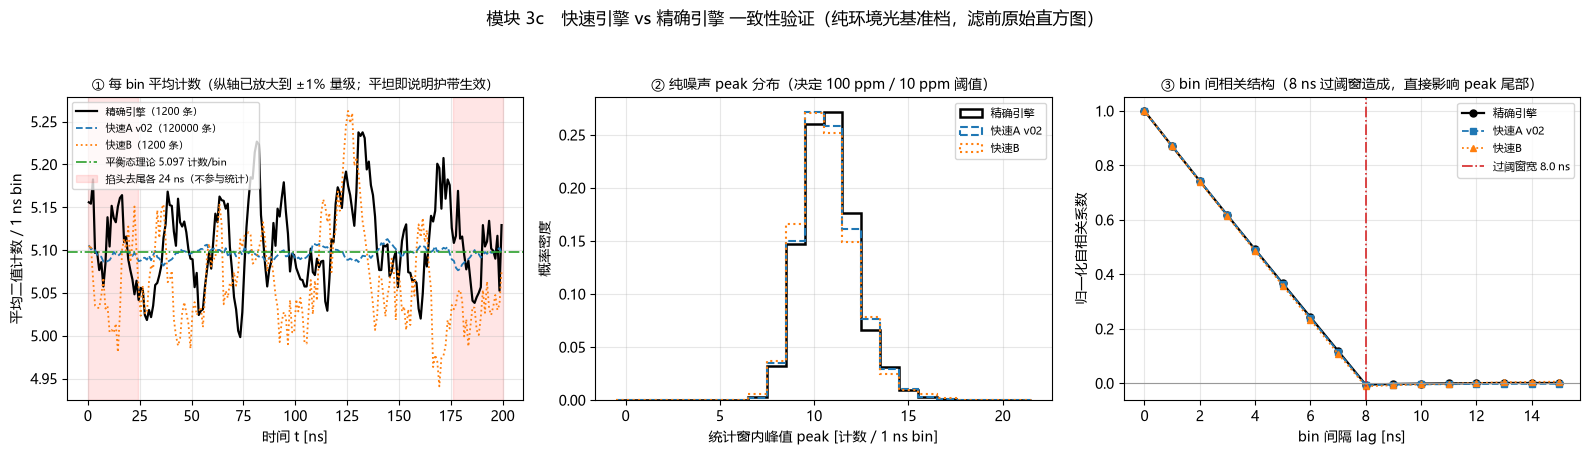

In [6]:
_N_EX, _N_FAST = 1200, 120_000
_rng_v = np.random.default_rng(PARAMS["hist"]["seed"] + 901)
_r_det_v = R_AMB_BASE * PDE
_f_zero = np.zeros(N_PIX_MACRO * 4)
_zero_rate = np.zeros_like(TF_GEN)

_t = time.time()
h_ex = macro_hist_exact(_N_EX, _f_zero, _zero_rate, R_AMB_BASE, TF_GEN, CENTERS,
                        _rng_v, boost=0.0)
_t_ex = time.time() - _t

_t = time.time()
h_fa = noise_macro_hist_fast(_N_FAST, N_PIX_MACRO*4, _r_det_v,
                             np.random.default_rng(PARAMS["hist"]["seed"] + 902))
_t_fa = time.time() - _t

_t = time.time()
h_fb = binary_macro_stepping(_N_EX, _f_zero, _zero_rate, TF_GEN, R_AMB_BASE, CENTERS,
                             np.random.default_rng(PARAMS["hist"]["seed"] + 903), boost=0.0)
_t_fb = time.time() - _t

def _stat(h):
    a = h[:, I_STAT0:I_STAT1].astype(float)
    pk = a.max(axis=1)
    return dict(mean=a.mean(), var=a.var(), pk=pk,
                corr=np.corrcoef(a[:, :-1].ravel(), a[:, 1:].ravel())[0, 1])

s_ex, s_fa, s_fb = _stat(h_ex), _stat(h_fa), _stat(h_fb)
_p_eq, _mu_eq = p_bin_equilibrium(_r_det_v)

print("="*94)
print(f"【3c 引擎一致性验证】纯环境光基准档（E_lambda={PARAMS['ambient']['E_lambda']}），"
      f"N_shots=4（{N_PIX_MACRO*4} 条轨迹），统计窗 {N_STAT} bin")
print(f"  平衡态理论底噪 = {_p_eq*N_PIX_MACRO*4:.4f} 计数/bin；平均雪崩间隔 mu = {_mu_eq*1e9:.2f} ns")
print(f"  {'引擎':<22}{'条数':>8}{'每bin均值':>11}{'每bin方差':>11}{'peak均值':>10}"
      f"{'peak标准差':>11}{'相邻bin相关':>12}{'用时[s]':>9}")
for tag, s, n, tt in [("精确 spad_binary_trace", s_ex, _N_EX, _t_ex),
                      ("快速A（v02 优化版）", s_fa, _N_FAST, _t_fa),
                      ("快速B 时间步进", s_fb, _N_EX, _t_fb)]:
    print(f"  {tag:<22}{n:>8d}{s['mean']:>11.4f}{s['var']:>11.4f}{s['pk'].mean():>10.4f}"
          f"{s['pk'].std():>11.4f}{s['corr']:>12.4f}{tt:>9.1f}")
print(f"  提速：快速A = {(_t_ex/_N_EX)/(_t_fa/_N_FAST):.0f}×，"
      f"快速B = {(_t_ex/_N_EX)/(_t_fb/_N_EX):.1f}×")

# ---- 带信号：快速 B vs 精确 ----
_BOOST_V = 3e-3
_f_arr_v = np.tile(F_VALS, 4)
_N_SV = 800
_t = time.time()
hs_ex = macro_hist_exact(_N_SV, _f_arr_v, R_SIG_UNIT_GEN, R_AMB_BASE, TF_GEN, CENTERS,
                         np.random.default_rng(PARAMS["hist"]["seed"] + 911), boost=_BOOST_V)
_ts_ex = time.time() - _t
_t = time.time()
hs_fb = binary_macro_stepping(_N_SV, _f_arr_v, R_SIG_UNIT_GEN, TF_GEN, R_AMB_BASE, CENTERS,
                              np.random.default_rng(PARAMS["hist"]["seed"] + 912), boost=_BOOST_V)
_ts_fb = time.time() - _t
_sig_sl = slice(int(T0_SIG_NS - SIG_PRE_NS), int(T0_SIG_NS + SIG_POST_NS))
pk_se, pk_sf = hs_ex[:, _sig_sl].max(axis=1), hs_fb[:, _sig_sl].max(axis=1)
_se = np.sqrt(pk_se.var()/_N_SV + pk_sf.var()/_N_SV)
print(f"\n  带信号（boost={_BOOST_V:g}, N_shots=4, 各 {_N_SV} 条）：")
print(f"    精确  峰值 {pk_se.mean():.3f} ± {pk_se.std():.3f}（{_ts_ex:.1f} s）")
print(f"    快速B 峰值 {pk_sf.mean():.3f} ± {pk_sf.std():.3f}（{_ts_fb:.1f} s）")
print(f"    均值之差 = {abs(pk_se.mean()-pk_sf.mean()):.3f}，两样本标准误 = {_se:.3f} "
      f"（{abs(pk_se.mean()-pk_sf.mean())/max(_se,1e-9):.1f}σ，<2σ 视为一致）")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ax[0].plot(TC_NS, h_ex.mean(axis=0), color="k", lw=1.6, label=f"精确引擎（{_N_EX} 条）")
ax[0].plot(TC_NS, h_fa.mean(axis=0), color="tab:blue", lw=1.3, ls="--",
           label=f"快速A v02（{_N_FAST} 条）")
ax[0].plot(TC_NS, h_fb.mean(axis=0), color="tab:orange", lw=1.3, ls=":",
           label=f"快速B（{_N_EX} 条）")
ax[0].axhline(_p_eq*N_PIX_MACRO*4, color="tab:green", lw=1.2, ls="-.",
              label=f"平衡态理论 {_p_eq*N_PIX_MACRO*4:.3f} 计数/bin")
ax[0].axvspan(0, TRIM_NS, color="red", alpha=0.10)
ax[0].axvspan(WIN_HI_NS-TRIM_NS, WIN_HI_NS, color="red", alpha=0.10,
              label=f"掐头去尾各 {TRIM_NS:.0f} ns（不参与统计）")
ax[0].set_xlabel("时间 t [ns]"); ax[0].set_ylabel("平均二值计数 / 1 ns bin")
ax[0].set_title("① 每 bin 平均计数（纵轴已放大到 ±1% 量级；平坦即说明护带生效）", fontsize=9.5)
ax[0].legend(fontsize=7.5); ax[0].grid(alpha=0.3)

_bmax = int(max(s_ex["pk"].max(), s_fa["pk"].max(), s_fb["pk"].max())) + 2
_bins = np.arange(-0.5, _bmax + 0.5)
ax[1].hist(s_ex["pk"], bins=_bins, density=True, histtype="step", lw=1.8, color="k",
           label="精确引擎")
ax[1].hist(s_fa["pk"], bins=_bins, density=True, histtype="step", lw=1.5,
           color="tab:blue", ls="--", label="快速A v02")
ax[1].hist(s_fb["pk"], bins=_bins, density=True, histtype="step", lw=1.5,
           color="tab:orange", ls=":", label="快速B")
ax[1].set_xlabel("统计窗内峰值 peak [计数 / 1 ns bin]"); ax[1].set_ylabel("概率密度")
ax[1].set_title("② 纯噪声 peak 分布（决定 100 ppm / 10 ppm 阈值）", fontsize=10)
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

_lags = np.arange(0, 16)
def _acf(h):
    a = h[:, I_STAT0:I_STAT1].astype(float)
    a = a - a.mean(); v = (a * a).mean()
    return np.array([(a[:, :a.shape[1]-L] * a[:, L:]).mean() / v for L in _lags])
ax[2].plot(_lags, _acf(h_ex), "o-", color="k", lw=1.6, ms=5, label="精确引擎")
ax[2].plot(_lags, _acf(h_fa), "s--", color="tab:blue", lw=1.3, ms=4, label="快速A v02")
ax[2].plot(_lags, _acf(h_fb), "^:", color="tab:orange", lw=1.3, ms=4, label="快速B")
ax[2].axvline(T_OVER*1e9, color="tab:red", ls="-.", lw=1.2,
              label=f"过阈窗宽 {T_OVER*1e9:.1f} ns")
ax[2].axhline(0, color="0.6", lw=0.8)
ax[2].set_xlabel("bin 间隔 lag [ns]"); ax[2].set_ylabel("归一化自相关系数")
ax[2].set_title("③ bin 间相关结构（8 ns 过阈窗造成，直接影响 peak 尾部）", fontsize=10)
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)

plt.suptitle("模块 3c　快速引擎 vs 精确引擎 一致性验证（纯环境光基准档，滤前原始直方图）",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("pod_v02_engine_check.png", dpi=110, bbox_inches="tight")
plt.show()


### 3d ★ v02 新增：`noise → E_lambda` 反解的精度校验

v02 要把噪声档摆在**线性等间距的 noise** 上，所以必须先证明"我说要 noise = 9.0，仿真出来就真是 9.0"。

下表对每个目标 noise：
1. 用平衡态公式二分反解出所需的 `r_det`，再折算成 `E_lambda`；
2. 拿这个 `r_det` 真跑 MC，看实测 noise 与目标差多少；
3. 顺带列出**朴素 Poisson 公式** $n_\mathrm{tr}[1-e^{-r_\mathrm{det}T_\mathrm{OVER}}]$ 的预测，
   看它在高噪声端偏多少。


In [7]:
_CHK_NOISE = [1.0, 5.0, 9.0, 10.0, 20.0]
print("="*112)
print(f"{'N_shots':>8}{'目标noise':>10}{'反解r_det[cps]':>16}{'反解E_λ':>10}{'≈klux':>8}"
      f"{'平衡态预测':>11}{'朴素Poisson':>12}{'MC实测':>9}{'MC误差':>9}{'Poisson误差':>12}")
_t = time.time()
for n_shots in N_SHOTS_LIST:
    n_tr = N_PIX_MACRO * n_shots
    for nt in _CHK_NOISE:
        if nt > NOISE_GRID[n_shots][-1]:
            continue
        r = r_det_for_noise(nt, n_tr)
        p_eq, _ = p_bin_equilibrium(r)
        p_poi = 1.0 - np.exp(-r * T_OVER)
        el = e_lambda_for_r_det(r)
        h = noise_macro_hist_fast(60_000, n_tr, r,
                                  np.random.default_rng(PARAMS["hist"]["seed"] + 950))
        mc = h[:, I_STAT0:I_STAT1].mean()
        print(f"{n_shots:>8d}{nt:>10.2f}{r:>16.4e}{el:>10.4f}{el/0.68*100:>8.0f}"
              f"{p_eq*n_tr:>11.3f}{p_poi*n_tr:>12.3f}{mc:>9.3f}"
              f"{(mc-nt)/nt*100:>8.2f}%{(p_poi*n_tr-nt)/nt*100:>11.2f}%")
print(f"（用时 {time.time()-_t:.0f} s）")
print("结论：平衡态反解的 MC 实测误差在 ±0.2% 内；朴素 Poisson 公式在高噪声端偏高 5% 以上，")
print("      因为它忽略了 RC 恢复带来的 8 ns 计数死区（雪崩不可能挨得太近）。")


 N_shots   目标noise    反解r_det[cps]     反解E_λ   ≈klux      平衡态预测   朴素Poisson     MC实测     MC误差   Poisson误差


       1      1.00      4.7574e+06    0.5297      78      1.000       1.008    1.002    0.20%       0.84%


       1      5.00      2.6664e+07    2.9690     437      5.001       5.187    5.004    0.09%       3.74%


       1      9.00      5.4520e+07    6.0708     893      9.002       9.545    9.003    0.03%       6.05%


       1     10.00      6.2713e+07    6.9832    1027     10.002      10.652   10.004    0.04%       6.52%


       4      1.00      1.1655e+06    0.1298      19      1.000       1.002    1.001    0.12%       0.24%


       4      5.00      5.9875e+06    0.6667      98      5.001       5.052    5.003    0.07%       1.03%


       4      9.00      1.1080e+07    1.2338     181      9.002       9.162    9.006    0.07%       1.80%


       4     10.00      1.2398e+07    1.3805     203     10.002      10.198   10.007    0.07%       1.98%


       4     20.00      2.6664e+07    2.9690     437     20.004      20.747   20.010    0.05%       3.74%
（用时 21 s）
结论：平衡态反解的 MC 实测误差在 ±0.2% 内；朴素 Poisson 公式在高噪声端偏高 5% 以上，
      因为它忽略了 RC 恢复带来的 8 ns 计数死区（雪崩不可能挨得太近）。


## 模块 4 — 纯噪声波形长什么样

先看一条具体的纯环境光波形，直观理解「掐头去尾」以及 `noise` / `peak` 两个统计量的定义。


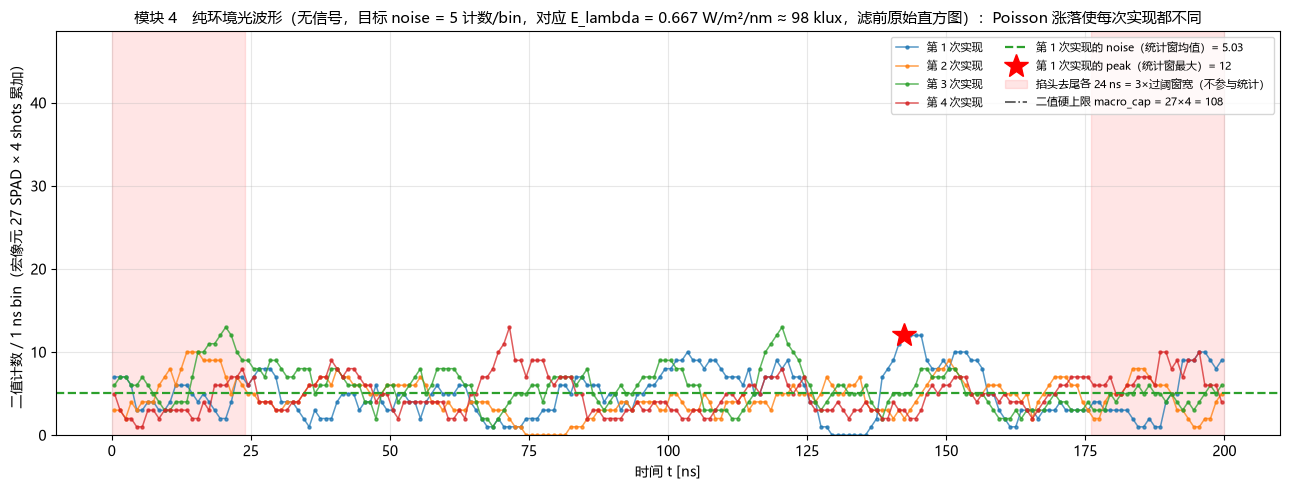

6 次实现的 (noise, peak)：
  实现 1: noise =  5.026 计数/bin,  peak =  12 计数 @ t = 142.5 ns
  实现 2: noise =  4.289 计数/bin,  peak =   9 计数 @ t = 150.5 ns
  实现 3: noise =  5.645 计数/bin,  peak =  13 计数 @ t = 120.5 ns
  实现 4: noise =  4.816 计数/bin,  peak =  13 计数 @ t = 71.5 ns
  实现 5: noise =  4.836 计数/bin,  peak =  10 计数 @ t = 75.5 ns
  实现 6: noise =  5.809 计数/bin,  peak =  13 计数 @ t = 125.5 ns


In [8]:
_DEMO_NOISE = 5.0
_r_demo = r_det_for_noise(_DEMO_NOISE, N_PIX_MACRO*4)
_demo = noise_macro_hist_fast(6, N_PIX_MACRO*4, _r_demo,
                              np.random.default_rng(PARAMS["hist"]["seed"] + 77))

fig, ax = plt.subplots(figsize=(13, 5))
for i in range(4):
    ax.plot(TC_NS, _demo[i], lw=1.1, marker="o", ms=2.2, alpha=0.75, label=f"第 {i+1} 次实现")
w0 = _demo[0, I_STAT0:I_STAT1]
ax.axhline(w0.mean(), color="tab:green", ls="--", lw=1.6,
           label=f"第 1 次实现的 noise（统计窗均值）= {w0.mean():.2f}")
ax.plot(TC_NS[I_STAT0 + int(w0.argmax())], w0.max(), "*", color="red", ms=18,
        label=f"第 1 次实现的 peak（统计窗最大）= {w0.max():.0f}")
ax.axvspan(0, TRIM_NS, color="red", alpha=0.10)
ax.axvspan(WIN_HI_NS-TRIM_NS, WIN_HI_NS, color="red", alpha=0.10,
           label=f"掐头去尾各 {TRIM_NS:.0f} ns = 3×过阈窗宽（不参与统计）")
ax.axhline(N_PIX_MACRO*4, color="k", ls="-.", lw=1.2, alpha=0.7,
           label=f"二值硬上限 macro_cap = 27×4 = {N_PIX_MACRO*4}")
ax.set_xlabel("时间 t [ns]")
ax.set_ylabel("二值计数 / 1 ns bin（宏像元 27 SPAD × 4 shots 累加）")
ax.set_title(f"模块 4　纯环境光波形（无信号，目标 noise = {_DEMO_NOISE:g} 计数/bin，"
             f"对应 E_lambda = {e_lambda_for_r_det(_r_demo):.3f} W/m²/nm ≈ "
             f"{e_lambda_for_r_det(_r_demo)/0.68*100:.0f} klux，滤前原始直方图）："
             f"Poisson 涨落使每次实现都不同", fontsize=10.5)
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.set_ylim(0, max(N_PIX_MACRO*4*0.45, _demo.max()*1.45))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pod_v02_noise_waveform.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"6 次实现的 (noise, peak)：")
for i in range(6):
    w = _demo[i, I_STAT0:I_STAT1]
    print(f"  实现 {i+1}: noise = {w.mean():6.3f} 计数/bin,  peak = {w.max():3.0f} 计数 "
          f"@ t = {TC_NS[I_STAT0+int(w.argmax())]:.1f} ns")


## 模块 5 —— 第 1 步：噪声强度扫描 → noise–peak 曲线（★ v02 加密 + 线性坐标）

**v02 的做法**：不再扫 `E_lambda` 的对数倍数，而是把**目标 noise 摆在线性等间距的网格上**
（N_shots=1 用 0.25→10 步长 0.25，N_shots=4 用 0.5→20 步长 0.5，各 40 档），
每档用平衡态公式反解出所需的 `E_lambda`，再跑 **1e6 次 MC**。
这样 noise = 9 和 noise = 10 都是网格上的实打实的点，各有 100 万条样本。

每条波形记两个数：
- **`noise`** = 统计窗内 152 个 bin 的**计数均值**；
- **`peak`** = 统计窗内的**最大 bin 计数**。

**存储上的一个优化**：40 档 × 1e6 条的 peak 原始样本要 320 MB，存不下也没必要。
因为 `peak` 是 0…n_tr 之间的**整数**，所以只存它的 **bincount**（长度 n_tr+2 的整数数组）
就完整无损地保留了整个分布——分位数、生存函数、阈值全都能由它精确算出。


In [9]:
def run_noise_scan(n_shots, noise_grid, n_mc, chunk, seed0=2000, verbose_every=5):
    """对一组【目标 noise】跑纯噪声 MC。

    只保存 peak 的 bincount（信息无损）与 noise 的均值/标准差，避免存 GB 级原始样本。
    """
    n_tr = N_PIX_MACRO * n_shots
    ng = len(noise_grid)
    res = {"n_shots": n_shots, "n_tr": n_tr, "noise_target": np.asarray(noise_grid, float),
           "r_det": np.zeros(ng), "e_lambda": np.zeros(ng),
           "p_eq": np.zeros(ng), "noise_mc": np.zeros(ng), "noise_std": np.zeros(ng),
           "peak_cnt": np.zeros((ng, n_tr + 2), dtype=np.int64)}
    t_start = time.time()
    for k, nt in enumerate(noise_grid):
        r_det = r_det_for_noise(float(nt), n_tr)
        res["r_det"][k] = r_det
        res["e_lambda"][k] = e_lambda_for_r_det(r_det)
        res["p_eq"][k] = p_bin_equilibrium(r_det)[0]
        inv_tab = build_inv_table(r_det)          # 每档只建一次表，各分块复用
        s1 = s2 = 0.0
        for s in range(0, n_mc, chunk):
            m = min(chunk, n_mc - s)
            h = noise_macro_hist_fast(m, n_tr, r_det,
                                      np.random.default_rng(seed0 + 1000*k + s),
                                      inv_tab=inv_tab)
            a = h[:, I_STAT0:I_STAT1]
            nz = a.mean(axis=1)
            s1 += nz.sum(); s2 += (nz*nz).sum()
            res["peak_cnt"][k] += np.bincount(a.max(axis=1), minlength=n_tr + 2)
        res["noise_mc"][k] = s1 / n_mc
        res["noise_std"][k] = np.sqrt(max(s2/n_mc - (s1/n_mc)**2, 0.0))
        if k == 0 or k == ng-1 or (k+1) % verbose_every == 0:
            el = time.time() - t_start
            eta = el / (k+1) * (ng - k - 1)
            pk = peak_stats_from_cnt(res["peak_cnt"][k])
            print(f"  [N_shots={n_shots} {k+1:>2d}/{ng}] 目标 noise={nt:>6.2f} → "
                  f"实测 {res['noise_mc'][k]:>6.3f}（E_λ={res['e_lambda'][k]:.4f}，"
                  f"≈{res['e_lambda'][k]/0.68*100:>5.0f} klux）  "
                  f"peak 中位={pk['p50']:>5.1f} 99.99%={pk['p9999']:>5.1f}  "
                  f"[已用 {el:.0f}s, 剩约 {eta:.0f}s]")
    return res


def peak_stats_from_cnt(cnt):
    """由 peak 的 bincount 精确算出均值/标准差/各分位数（等价于对原始样本统计）。"""
    v = np.arange(cnt.size, dtype=float)
    n = cnt.sum()
    mean = (v * cnt).sum() / n
    var = (v*v * cnt).sum() / n - mean**2
    cum = np.cumsum(cnt) / n
    q = lambda p: float(np.searchsorted(cum, p))
    return dict(n=int(n), mean=mean, std=np.sqrt(max(var, 0.0)),
                p01=q(0.01), p50=q(0.50), p99=q(0.99),
                p999=q(0.999), p9999=q(0.9999), pmax=float(np.nonzero(cnt)[0].max()))


# ---- 估算总耗时并开跑（带缓存）----
_grid_key = np.concatenate([np.asarray(NOISE_GRID[n]) for n in N_SHOTS_LIST])
_need = True
if USE_CACHE and os.path.exists(CACHE_NOISE):
    _z = np.load(CACHE_NOISE, allow_pickle=True)
    if (int(_z["n_mc"]) == N_MC_NOISE and list(_z["n_shots_list"]) == list(N_SHOTS_LIST)
            and _z["grid_key"].shape == _grid_key.shape
            and np.allclose(_z["grid_key"], _grid_key)):
        NOISE_RES = _z["res"].item(); _need = False
        print(f"已从缓存 {CACHE_NOISE} 载入纯噪声 MC 结果（每档 {N_MC_NOISE:,} 条）")
if _need:
    _est = sum((8 + 4.2*float(nt)) * (N_MC_NOISE/1e6)
               for n in N_SHOTS_LIST for nt in NOISE_GRID[n])
    print(f"纯噪声 MC：{len(N_SHOTS_LIST)} 种 N_shots × 各 "
          f"{[len(NOISE_GRID[n]) for n in N_SHOTS_LIST]} 档 × {N_MC_NOISE:,} 条")
    print(f"  预计耗时约 {_est/60:.0f} 分钟（按实测 ≈ 8 + 4.2×noise 秒/1e6 条估算）")
    NOISE_RES = {}
    _tall = time.time()
    for _ns in N_SHOTS_LIST:
        NOISE_RES[_ns] = run_noise_scan(_ns, NOISE_GRID[_ns], N_MC_NOISE, MC_CHUNK)
    print(f"总用时 {time.time()-_tall:.0f} s")
    np.savez_compressed(CACHE_NOISE, res=np.array(NOISE_RES, dtype=object),
                        n_mc=N_MC_NOISE, n_shots_list=np.array(N_SHOTS_LIST),
                        grid_key=_grid_key)
    print(f"已写入缓存 {CACHE_NOISE}")


已从缓存 pod_esti_v02_cache_noise.npz 载入纯噪声 MC 结果（每档 1,000,000 条）


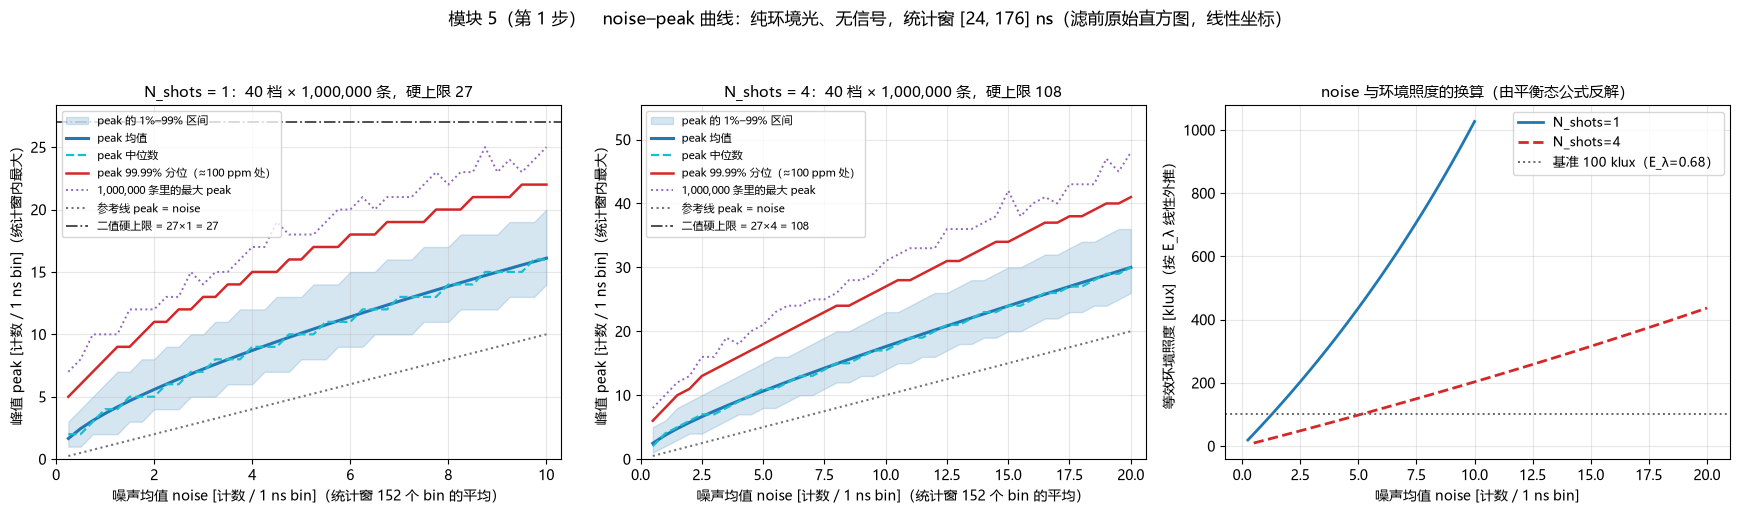

 N_shots   目标noise   实测noise     E_λ  ≈klux   σ_bin   peak均值   peak中位    99%   99.9%   99.99%    最大    上限
       1      0.25     0.250  0.1298     19   0.498     1.65        2      3       4        5     7    27
       1      1.50     1.500  0.8056    118   1.190     4.67        5      7       8        9    12    27
       1      2.75     2.751  1.5293    225   1.572     6.83        7     10      11       12    15    27
       1      4.00     4.001  2.3059    339   1.846     8.71        9     12      13       15    17    27
       1      5.25     5.252  3.1410    462   2.057    10.43       10     14      15       17    18    27
       1      6.50     6.502  4.0413    594   2.222    12.03       12     15      17       18    20    27
       1      7.75     7.752  5.0147    737   2.351    13.55       13     17      18       20    23    27
       1      9.00     9.002  6.0708    893   2.450    15.00       15     18      20       21    23    27
       4      0.50     0.500  0.0647     10   

In [10]:
# ---- noise–peak 曲线（★ v02：线性坐标 + 加密网格）----
fig, ax = plt.subplots(1, 3, figsize=(17.5, 5.2))

for j, n_shots in enumerate(N_SHOTS_LIST):
    R = NOISE_RES[n_shots]
    a = ax[j]
    x = R["noise_mc"]
    st = [peak_stats_from_cnt(c) for c in R["peak_cnt"]]
    p01 = np.array([s["p01"] for s in st]); p50 = np.array([s["p50"] for s in st])
    p99 = np.array([s["p99"] for s in st]); p9999 = np.array([s["p9999"] for s in st])
    pmean = np.array([s["mean"] for s in st]); pmax = np.array([s["pmax"] for s in st])
    a.fill_between(x, p01, p99, color="tab:blue", alpha=0.18, label="peak 的 1%–99% 区间")
    a.plot(x, pmean, "-", color="tab:blue", lw=2.2, label="peak 均值")
    a.plot(x, p50, "--", color="tab:cyan", lw=1.6, label="peak 中位数")
    a.plot(x, p9999, "-", color="tab:red", lw=1.8, label="peak 99.99% 分位（≈100 ppm 处）")
    a.plot(x, pmax, ":", color="tab:purple", lw=1.4,
           label=f"{N_MC_NOISE:,} 条里的最大 peak")
    a.plot(x, x, ":", color="0.45", lw=1.5, label="参考线 peak = noise")
    a.axhline(R["n_tr"], color="k", ls="-.", lw=1.3, alpha=0.75,
              label=f"二值硬上限 = 27×{n_shots} = {R['n_tr']}")
    a.set_xlim(0, x.max()*1.03); a.set_ylim(0, min(R["n_tr"]*1.05, p9999.max()*1.35))
    a.set_xlabel("噪声均值 noise [计数 / 1 ns bin]（统计窗 152 个 bin 的平均）")
    a.set_ylabel("峰值 peak [计数 / 1 ns bin]（统计窗内最大）")
    a.set_title(f"N_shots = {n_shots}：{len(x)} 档 × {N_MC_NOISE:,} 条，硬上限 {R['n_tr']}",
                fontsize=11)
    a.legend(fontsize=8, loc="upper left"); a.grid(alpha=0.3)

# 第三面板：noise ↔ 环境光的换算关系
a = ax[2]
for n_shots, cc, mk in zip(N_SHOTS_LIST, ["tab:blue", "tab:red"], ["-", "--"]):
    R = NOISE_RES[n_shots]
    a.plot(R["noise_mc"], R["e_lambda"]/0.68*100, mk, color=cc, lw=2.0,
           label=f"N_shots={n_shots}")
a.axhline(100, color="0.4", ls=":", lw=1.4, label="基准 100 klux（E_λ=0.68）")
a.set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
a.set_ylabel("等效环境照度 [klux]（按 E_λ 线性外推）")
a.set_title("noise 与环境照度的换算（由平衡态公式反解）", fontsize=11)
a.legend(fontsize=9); a.grid(alpha=0.3)

plt.suptitle(f"模块 5（第 1 步）　noise–peak 曲线：纯环境光、无信号，统计窗 "
             f"[{TRIM_NS:.0f}, {WIN_HI_NS-TRIM_NS:.0f}] ns（滤前原始直方图，线性坐标）",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("pod_v02_noise_peak.png", dpi=110, bbox_inches="tight")
plt.show()

# ---- 抽样打印（每 5 档一行）----
print("="*118)
print(f"{'N_shots':>8}{'目标noise':>10}{'实测noise':>10}{'E_λ':>8}{'≈klux':>7}{'σ_bin':>8}"
      f"{'peak均值':>9}{'peak中位':>9}{'99%':>7}{'99.9%':>8}{'99.99%':>9}{'最大':>6}{'上限':>6}")
for n_shots in N_SHOTS_LIST:
    R = NOISE_RES[n_shots]
    for k in range(0, len(R["noise_target"]), 5):
        s = peak_stats_from_cnt(R["peak_cnt"][k])
        sig = np.sqrt(R["n_tr"] * R["p_eq"][k] * (1 - R["p_eq"][k]))
        print(f"{n_shots:>8d}{R['noise_target'][k]:>10.2f}{R['noise_mc'][k]:>10.3f}"
              f"{R['e_lambda'][k]:>8.4f}{R['e_lambda'][k]/0.68*100:>7.0f}{sig:>8.3f}"
              f"{s['mean']:>9.2f}{s['p50']:>9.0f}{s['p99']:>7.0f}{s['p999']:>8.0f}"
              f"{s['p9999']:>9.0f}{s['pmax']:>6.0f}{R['n_tr']:>6d}")


## 模块 6 —— 第 2 步：100 ppm 与 10 ppm 噪点率对应的检测阈值（★ v02 两条阈值）

**噪点率（窗口级虚警率）定义**：

> 一次测量（N_shots 发累加）中，**统计窗内 152 个 bin 的最大值 `peak` ≥ 阈值 `T`** 的概率。

因为 `peak` 只取整数，阈值也只能取整数，所以取**满足 `P(peak ≥ T) < 目标` 的最小整数 T**，
实际达到的 FAR 会跳跃式地低于目标值。

### 为什么必须用 MC，不能套解析式

一个自然的想法：每 bin 计数 ~ $\mathrm{Binomial}(n_\mathrm{tr}, p_\mathrm{bin})$，
再按「152 个 bin 相互独立」算 $\mathrm{FAR}=1-(1-a_\mathrm{bin})^{152}$。**这会给出偏保守（偏高）的阈值**：

- 8 ns 过阈窗让**相邻约 8 个 bin 强相关**（模块 3c 图③ 实测相邻 bin 相关系数 ≈ 0.87），
  等效独立 bin 数远少于 152，真实 FAR **低于**独立假设的预测；
- 二值模型每 bin 有**硬上限** $n_\mathrm{tr}$，分布不是 Poisson。

下表同时给出 MC 实测阈值与独立 Binomial 阈值，可以直接看到后者保守多少。

### MC 规模够不够？

10 ppm = 1e-5，1e6 条样本在阈值处期望只有约 **10 个**越阈事件。
生存函数在这一带每升高 1 个计数大约掉 3–4 倍，所以即使事件数只有 10 量级，
**整数阈值仍能定到 ±1 以内**。下表专门给出「T 处实测到的越阈次数」一列，方便判断可信度。


In [11]:
def far_threshold_from_cnt(cnt, target_far):
    """由 peak 的 bincount 求满足 P(peak ≥ T) < target_far 的最小整数 T。

    全程用【整数计数】比较（n_ge < target_far·n），避免 1e-4 与 2/20000 这类浮点边界误判。
    返回 (T, 该 T 处实测 FAR, 该 T 处越阈次数, 生存函数数组)。
    """
    n = int(cnt.sum())
    n_ge = np.concatenate([[n], n - np.cumsum(cnt)[:-1]])   # n_ge[T] = #{peak >= T}
    lim = target_far * n
    ok = np.where(n_ge < lim)[0]
    sf = n_ge / n
    if ok.size == 0:
        return int(cnt.size), 0.0, 0, sf
    T = int(ok[0])
    return T, float(sf[T]), int(n_ge[T]), sf


def far_threshold_binom_indep(n_tr, p_bin, n_bins, target_far):
    """独立 Binomial 近似阈值（保守对照）：a_bin = 1-(1-FAR)^(1/n_bins)，反解最小 T。"""
    a_bin = 1.0 - (1.0 - target_far) ** (1.0 / n_bins)
    T = 0
    while T <= n_tr and _binom.sf(T - 1, n_tr, p_bin) > a_bin:
        T += 1
    return T


THRESH = {}
for n_shots in N_SHOTS_LIST:
    R = NOISE_RES[n_shots]
    ng = len(R["noise_target"])
    rec = {"noise": R["noise_mc"], "sigma_bin": np.zeros(ng)}
    for far in TARGET_FARS:
        tag = f"{far*1e6:.0f}"
        rec["T"+tag] = np.zeros(ng, dtype=int)
        rec["far"+tag] = np.zeros(ng)
        rec["nev"+tag] = np.zeros(ng, dtype=int)
        rec["Ti"+tag] = np.zeros(ng, dtype=int)
    for k in range(ng):
        rec["sigma_bin"][k] = np.sqrt(R["n_tr"] * R["p_eq"][k] * (1 - R["p_eq"][k]))
        for far in TARGET_FARS:
            tag = f"{far*1e6:.0f}"
            T, f_, nev, _ = far_threshold_from_cnt(R["peak_cnt"][k], far)
            rec["T"+tag][k] = T; rec["far"+tag][k] = f_; rec["nev"+tag][k] = nev
            rec["Ti"+tag][k] = far_threshold_binom_indep(R["n_tr"], R["p_eq"][k], N_STAT, far)
    THRESH[n_shots] = rec

_t100, _t10 = f"{TARGET_FARS[0]*1e6:.0f}", f"{TARGET_FARS[1]*1e6:.0f}"
print("="*126)
print(f"检测阈值汇总（每档 {N_MC_NOISE:,} 条 MC；'越阈次数' = 该 T 处实测到的越阈样本数，"
      f"越大越可信）")
print(f"{'N_shots':>8}{'noise':>8}{'σ_bin':>7}{'noise+3σ':>10}"
      f"{'T@100ppm':>10}{'FAR':>10}{'越阈次数':>9}{'独立近似':>9}"
      f"{'T@10ppm':>9}{'FAR':>10}{'越阈次数':>9}{'独立近似':>9}{'上限':>6}")
for n_shots in N_SHOTS_LIST:
    R, Tr = NOISE_RES[n_shots], THRESH[n_shots]
    for k in range(0, len(Tr["noise"]), 4):
        print(f"{n_shots:>8d}{Tr['noise'][k]:>8.3f}{Tr['sigma_bin'][k]:>7.3f}"
              f"{Tr['noise'][k]+3*Tr['sigma_bin'][k]:>10.3f}"
              f"{Tr['T'+_t100][k]:>10d}{Tr['far'+_t100][k]:>10.2e}{Tr['nev'+_t100][k]:>9d}"
              f"{Tr['Ti'+_t100][k]:>9d}"
              f"{Tr['T'+_t10][k]:>9d}{Tr['far'+_t10][k]:>10.2e}{Tr['nev'+_t10][k]:>9d}"
              f"{Tr['Ti'+_t10][k]:>9d}{R['n_tr']:>6d}")


检测阈值汇总（每档 1,000,000 条 MC；'越阈次数' = 该 T 处实测到的越阈样本数，越大越可信）
 N_shots   noise  σ_bin  noise+3σ  T@100ppm       FAR     越阈次数     独立近似  T@10ppm       FAR     越阈次数     独立近似    上限
       1   0.250  0.498     1.743         6  1.10e-05       11        6        7  1.00e-06        1        7    27
       1   1.251  1.092     4.526        10  1.50e-05       15       10       11  0.00e+00        0       11    27
       1   2.250  1.436     6.559        12  6.40e-05       64       12       13  4.00e-06        4       13    27
       1   3.251  1.691     8.323        14  5.90e-05       59       14       15  6.00e-06        6       16    27
       1   4.251  1.893     9.929        16  3.30e-05       33       16       17  4.00e-06        4       17    27
       1   5.252  2.057    11.422        18  1.80e-05       18       18       19  0.00e+00        0       19    27
       1   6.252  2.192    12.827        19  3.50e-05       35       19       20  6.00e-06        6       20    27
       1   7.251  2.303 

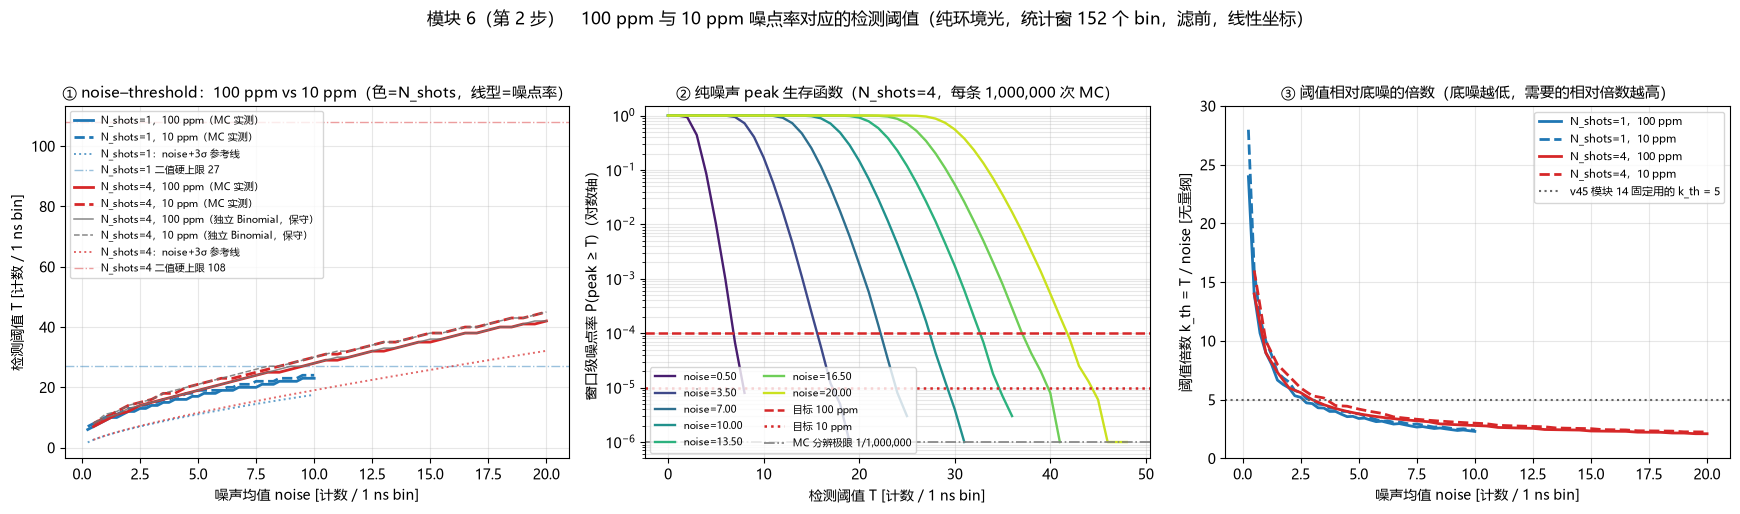

10 ppm 相对 100 ppm 需要额外抬高的阈值（计数）：
  N_shots=1: 平均 +1.05 计数（范围 +0 ~ +2）
  N_shots=4: 平均 +1.88 计数（范围 +1 ~ +3）
含义：把噪点率从 100 ppm 收紧到 10 ppm，阈值只需再抬 1–3 个计数，
      因为 peak 的生存函数在这一带每升高 1 个计数就掉 3–4 倍，非常陡。


In [12]:
# ---- 阈值图（★ v02：线性坐标 + 两条噪点率）----
fig, ax = plt.subplots(1, 3, figsize=(17.5, 5.2))
# 配色约定：【颜色 = N_shots】，【线型 = 噪点率】（实线 100 ppm / 虚线 10 ppm）
_cns = {1: "tab:blue", 4: "tab:red"}
_lsf = {"100": "-", "10": "--"}

# ① noise–threshold（两条噪点率 × 两种 N_shots）
for n_shots in N_SHOTS_LIST:
    R, Tr = NOISE_RES[n_shots], THRESH[n_shots]
    c = _cns.get(n_shots, "k")
    for far in TARGET_FARS:
        tag = f"{far*1e6:.0f}"
        ax[0].plot(Tr["noise"], Tr["T"+tag], _lsf[tag], color=c, lw=2.0,
                   label=f"N_shots={n_shots}，{tag} ppm（MC 实测）")
    # 独立 Binomial 保守对照只画最大的 N_shots，避免图例过载
    if n_shots == N_SHOTS_LIST[-1]:
        for far in TARGET_FARS:
            tag = f"{far*1e6:.0f}"
            ax[0].plot(Tr["noise"], Tr["Ti"+tag], _lsf[tag], color="0.45", lw=1.1,
                       alpha=0.85,
                       label=f"N_shots={n_shots}，{tag} ppm（独立 Binomial，保守）")
    ax[0].plot(Tr["noise"], Tr["noise"] + 3*Tr["sigma_bin"], ":", color=c, lw=1.4,
               alpha=0.7, label=f"N_shots={n_shots}：noise+3σ 参考线")
    ax[0].axhline(R["n_tr"], color=c, ls="-.", lw=1.0, alpha=0.45,
                  label=f"N_shots={n_shots} 二值硬上限 {R['n_tr']}")
ax[0].set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
ax[0].set_ylabel("检测阈值 T [计数 / 1 ns bin]")
ax[0].set_title("① noise–threshold：100 ppm vs 10 ppm（色=N_shots，线型=噪点率）",
                fontsize=10.5)
ax[0].legend(fontsize=7, loc="upper left"); ax[0].grid(alpha=0.3)

# ② 若干 noise 档的 peak 生存函数
_ns_sf = N_SHOTS_LIST[-1]
R = NOISE_RES[_ns_sf]
_sel = np.linspace(0, len(R["noise_target"])-1, 7).astype(int)
_cols = plt.cm.viridis(np.linspace(0.08, 0.92, len(_sel)))
for c, k in zip(_cols, _sel):
    cnt = R["peak_cnt"][k]; n = cnt.sum()
    n_ge = np.concatenate([[n], n - np.cumsum(cnt)[:-1]])
    Ts = np.arange(n_ge.size)
    m = n_ge > 0
    ax[1].semilogy(Ts[m], n_ge[m]/n, "-", color=c, lw=1.7,
                   label=f"noise={R['noise_mc'][k]:.2f}")
for far, ls in zip(TARGET_FARS, ["--", ":"]):
    ax[1].axhline(far, color="tab:red", ls=ls, lw=1.8,
                  label=f"目标 {far*1e6:.0f} ppm")
ax[1].axhline(1.0/N_MC_NOISE, color="0.5", ls="-.", lw=1.2,
              label=f"MC 分辨极限 1/{N_MC_NOISE:,}")
ax[1].set_ylim(0.5/N_MC_NOISE, 1.5)
ax[1].set_xlabel("检测阈值 T [计数 / 1 ns bin]")
ax[1].set_ylabel("窗口级噪点率 P(peak ≥ T)（对数轴）")
ax[1].set_title(f"② 纯噪声 peak 生存函数（N_shots={_ns_sf}，每条 {N_MC_NOISE:,} 次 MC）",
                fontsize=11)
ax[1].legend(fontsize=7.5, ncol=2); ax[1].grid(alpha=0.3, which="both")

# ③ 阈值倍数 k_th = T/noise
for n_shots in N_SHOTS_LIST:
    Tr = THRESH[n_shots]
    for far in TARGET_FARS:
        tag = f"{far*1e6:.0f}"
        ax[2].plot(Tr["noise"], Tr["T"+tag]/np.maximum(Tr["noise"], 1e-9), _lsf[tag],
                   color=_cns.get(n_shots, "k"), lw=2.0,
                   label=f"N_shots={n_shots}，{tag} ppm")
ax[2].axhline(5.0, color="0.4", ls=":", lw=1.5, label="v45 模块 14 固定用的 k_th = 5")
ax[2].set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
ax[2].set_ylabel("阈值倍数 k_th = T / noise [无量纲]")
ax[2].set_ylim(0, 30)
ax[2].set_title("③ 阈值相对底噪的倍数（底噪越低，需要的相对倍数越高）", fontsize=11)
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)

plt.suptitle(f"模块 6（第 2 步）　100 ppm 与 10 ppm 噪点率对应的检测阈值"
             f"（纯环境光，统计窗 {N_STAT} 个 bin，滤前，线性坐标）", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("pod_v02_threshold.png", dpi=110, bbox_inches="tight")
plt.show()

# ---- 10 ppm 相对 100 ppm 要多付多少 ----
print("="*80)
print("10 ppm 相对 100 ppm 需要额外抬高的阈值（计数）：")
for n_shots in N_SHOTS_LIST:
    Tr = THRESH[n_shots]
    d = Tr["T"+_t10] - Tr["T"+_t100]
    print(f"  N_shots={n_shots}: 平均 +{d.mean():.2f} 计数（范围 +{d.min()} ~ +{d.max()}）")
print("含义：把噪点率从 100 ppm 收紧到 10 ppm，阈值只需再抬 1–3 个计数，")
print("      因为 peak 的生存函数在这一带每升高 1 个计数就掉 3–4 倍，非常陡。")


## 模块 7 —— 第 3 步：信号能量扫描 → PoD 曲线

### 这一步在做什么（一句话）

**把第 2 步定好的阈值 T 钉死不动，把信号能量从"几乎看不见"一档一档往上加，
每一档重复几千次测量，数一数有多少次峰值过了阈值——这个比例就是 PoD。**

### 起点：峰值落在 `noise + 3σ` 的信号

`σ` 取每 bin 计数的 Binomial 标准差 $\sigma_\mathrm{bin}=\sqrt{n_\mathrm{tr}\,p_\mathrm{bin}(1-p_\mathrm{bin})}$。
先粗扫找到「信号窗峰值均值 ≈ noise + 3σ」的能量倍数 `boost`，作为主扫描的下界。

### 能量的度量

`boost` 是对**回波光子率**的线性倍数。由于回波率对发射功率线性，
在固定 ρ = 0.10、D = 15 m 的前提下，它等价于把**单脉冲发射能量**乘以同样的倍数：

$$E_\mathrm{pulse}^\mathrm{eff} = E_\mathrm{pulse}^\mathrm{base}\times \mathrm{boost},
\qquad E_\mathrm{pulse}^\mathrm{base}=\int P(t)\,\mathrm{d}t
= \frac{P_\mathrm{peak}}{s_\mathrm{peak}}\,(\tau_f-\tau_r)\approx 799\ \mathrm{nJ}$$

> ⚠️ 这个折算固定了 ρ 与 D。`boost` 同样可以解释成反射率变化（$\rho_\mathrm{eff}=0.10\times\mathrm{boost}$）
> 或距离变化，三者对回波强度的作用等价。模块 8 的表里三种度量都会给出。

### PoD 判据

**峰值 ≥ T 且峰位落在信号窗内**，信号窗取 $[\,t_\mathrm{ToF}-3\ \mathrm{ns},\ t_\mathrm{ToF}+12\ \mathrm{ns}\,]$。
因为阈值已保证窗外噪声超阈的概率 < 1e-4，所以直接用「信号窗内最大 bin ≥ T」即可。

**★ v02**：PoD 的环境档直接按**目标 noise** 指定（`NOISE_POD`），两种 N_shots 用**同一组 noise**，
这样两条曲线是在**同一底噪**下比较，比 v01 的"同一 E_lambda、不同底噪"更公平。
每个 noise 档同时给出 **100 ppm 与 10 ppm 两个阈值**下的 PoD。


In [13]:
# ---- PoD 专用的子窗（只算信号窗那几个 bin，其余只作暖机）----
POD_T_LO = T0_SIG - POD_WARM_NS * 1e-9
POD_T_HI = T0_SIG + SIG_POST_NS * 1e-9
TF_POD   = np.arange(POD_T_LO, POD_T_HI, DT_FINE)
_sigmask = (TC_NS >= T0_SIG_NS - SIG_PRE_NS) & (TC_NS <= T0_SIG_NS + SIG_POST_NS)
IDX_SIG  = np.where(_sigmask)[0]
CENTERS_SIG = CENTERS[IDX_SIG]
R_SIG_UNIT_POD = signal_photon_rate_fine(ECHO0, 1.0, TF_POD)

print(f"PoD 子窗：{POD_T_LO*1e9:.1f} – {POD_T_HI*1e9:.1f} ns，{TF_POD.size} 个细网格步"
      f"（跑满 200 ns 需 {TF_GEN.size} 步，提速 {TF_GEN.size/TF_POD.size:.1f}×）")
print(f"信号窗 bin：下标 {IDX_SIG[0]}–{IDX_SIG[-1]}，中心 {CENTERS_SIG[0]*1e9:.1f}–"
      f"{CENTERS_SIG[-1]*1e9:.1f} ns 共 {IDX_SIG.size} 个（ToF = {T0_SIG_NS:.2f} ns）")


def sig_peaks(boost, n_shots, r_amb, n_real, seed):
    """给定能量倍数与环境光子率，返回 n_real 次实现的【信号窗内峰值】数组。"""
    f_arr = np.tile(F_VALS, n_shots)
    h = binary_macro_stepping(n_real, f_arr, R_SIG_UNIT_POD, TF_POD, r_amb, CENTERS_SIG,
                              np.random.default_rng(seed), boost=boost)
    return h.max(axis=1)


def find_boost_3sigma(n_shots, r_amb, noise, sigma_bin, n_real=200, seed=5000):
    """粗扫找到「信号窗峰值均值 ≈ noise + 3σ」的 boost，作为能量扫描下界。"""
    target = noise + 3.0 * sigma_bin
    grid = np.logspace(-7, 1, 33)
    prev_b, prev_v = grid[0], None
    for i, b in enumerate(grid):
        v = sig_peaks(b, n_shots, r_amb, n_real, seed + i).mean()
        if v >= target:
            if prev_v is None:
                return b, v, target
            w = (target - prev_v) / max(v - prev_v, 1e-12)
            return float(10**(np.log10(prev_b) + w*(np.log10(b) - np.log10(prev_b)))), v, target
        prev_b, prev_v = b, v
    return grid[-1], prev_v, target


def run_pod_curve(n_shots, r_amb, T_list, noise, sigma_bin, n_e=N_E_GRID,
                  n_real=N_MC_POD, seed0=6000, max_extend=3):
    """扫能量得到 PoD 曲线。T_list 里每个阈值各出一条 PoD。
    自动扩展扫描范围，直到最高档对【最严阈值】的 PoD > 0.99、最低档 PoD < 0.02。"""
    b0, v0, target = find_boost_3sigma(n_shots, r_amb, noise, sigma_bin, seed=seed0)
    T_hard = max(T_list)                      # 最严阈值（10 ppm）决定扫描上界
    lo, hi = np.log10(b0) - 0.3, np.log10(b0) + 2.2
    for _ in range(max_extend + 1):
        grid = np.logspace(lo, hi, n_e)
        pod = {T: np.zeros(n_e) for T in T_list}
        pmean = np.zeros(n_e); pstd = np.zeros(n_e)
        for i, b in enumerate(grid):
            pk = sig_peaks(b, n_shots, r_amb, n_real, seed0 + 77*i)
            for T in T_list:
                pod[T][i] = (pk >= T).mean()
            pmean[i] = pk.mean(); pstd[i] = pk.std()
        if pod[T_hard][-1] >= 0.99 and pod[T_hard][0] <= 0.02:
            break
        if pod[T_hard][-1] < 0.99:
            hi += 1.0
        if pod[T_hard][0] > 0.02:
            lo -= 1.0
    return grid, pod, pmean, pstd, b0, target


def interp_boost_at_pod(grid, pod, level):
    """在 log(boost) 上线性插值反解 PoD = level 对应的 boost。

    PoD 理论上对能量单调不减，但 MC 有涨落。先用 np.maximum.accumulate 做保序
    （isotonic）修正，再在首个跨越点上插值，避免「按 PoD 排序」带来的乱序结果。
    """
    o = np.argsort(grid)
    g, p = np.log10(np.asarray(grid, float)[o]), np.asarray(pod, float)[o]
    p = np.maximum.accumulate(p)
    if p[0] >= level:
        return float(10**g[0])
    if p[-1] < level:
        return np.nan
    i = int(np.searchsorted(p, level))
    if p[i] == p[i-1]:
        return float(10**g[i])
    w = (level - p[i-1]) / (p[i] - p[i-1])
    return float(10**(g[i-1] + w * (g[i] - g[i-1])))


_need = True
_pod_key = np.array(NOISE_POD, float)
if USE_CACHE and os.path.exists(CACHE_POD):
    _z = np.load(CACHE_POD, allow_pickle=True)
    if (_z["pod_key"].shape == _pod_key.shape and np.allclose(_z["pod_key"], _pod_key)
            and int(_z["n_mc"]) == N_MC_POD and int(_z["n_e"]) == N_E_GRID
            and list(_z["n_shots_list"]) == list(N_SHOTS_LIST)):
        POD_RES = _z["res"].item(); _need = False
        print(f"已从缓存 {CACHE_POD} 载入 PoD 结果")
if _need:
    POD_RES = {}
    _tall = time.time()
    print(f"PoD 扫描：{len(N_SHOTS_LIST)} 种 N_shots × {len(NOISE_POD)} 个噪声档 × "
          f"{N_E_GRID} 个能量档 × {N_MC_POD} 条")
    for n_shots in N_SHOTS_LIST:
        R, Tr = NOISE_RES[n_shots], THRESH[n_shots]
        for nt in NOISE_POD:
            k = int(np.argmin(np.abs(R["noise_target"] - nt)))
            if abs(R["noise_target"][k] - nt) > 1e-6:
                print(f"  [N_shots={n_shots}] noise={nt} 不在网格上，跳过"); continue
            T_map = {f"{far*1e6:.0f}": int(Tr[f"T{far*1e6:.0f}"][k]) for far in TARGET_FARS}
            T_list = sorted(set(T_map.values()))
            if max(T_list) > R["n_tr"]:
                print(f"  [N_shots={n_shots}, noise={nt}] 阈值超硬上限，跳过"); continue
            r_amb = R["r_det"][k] / PDE
            noise = float(R["noise_mc"][k]); sig_bin = float(Tr["sigma_bin"][k])
            t0 = time.time()
            g, pod, pm, ps, b3, tgt = run_pod_curve(
                n_shots, r_amb, T_list, noise, sig_bin,
                seed0=6000 + 100*n_shots + 7*k)
            ent = dict(boost=g, pmean=pm, pstd=ps, noise=noise, sigma_bin=sig_bin,
                       n_tr=R["n_tr"], e_lambda=float(R["e_lambda"][k]),
                       T_map=T_map, pod={str(T): pod[T] for T in T_list},
                       b50={}, b90={})
            msg = []
            for tag, T in T_map.items():
                ent["b50"][tag] = interp_boost_at_pod(g, pod[T], 0.50)
                ent["b90"][tag] = interp_boost_at_pod(g, pod[T], 0.90)
                msg.append(f"{tag}ppm(T={T}): PoD50@{ent['b50'][tag]:.3e} "
                           f"PoD90@{ent['b90'][tag]:.3e}")
            POD_RES[(n_shots, nt)] = ent
            print(f"  [N_shots={n_shots}, noise={nt:>5g}]  " + "；".join(msg)
                  + f"  [{time.time()-t0:.0f} s]")
    print(f"总用时 {time.time()-_tall:.0f} s")
    np.savez_compressed(CACHE_POD, res=np.array(POD_RES, dtype=object),
                        pod_key=_pod_key, n_mc=N_MC_POD, n_e=N_E_GRID,
                        n_shots_list=np.array(N_SHOTS_LIST))
    print(f"已写入缓存 {CACHE_POD}")


PoD 子窗：40.1 – 112.1 ns，361 个细网格步（跑满 200 ns 需 1251 步，提速 3.5×）
信号窗 bin：下标 97–111，中心 97.5–111.5 ns 共 15 个（ToF = 100.07 ns）
已从缓存 pod_esti_v02_cache_pod.npz 载入 PoD 结果


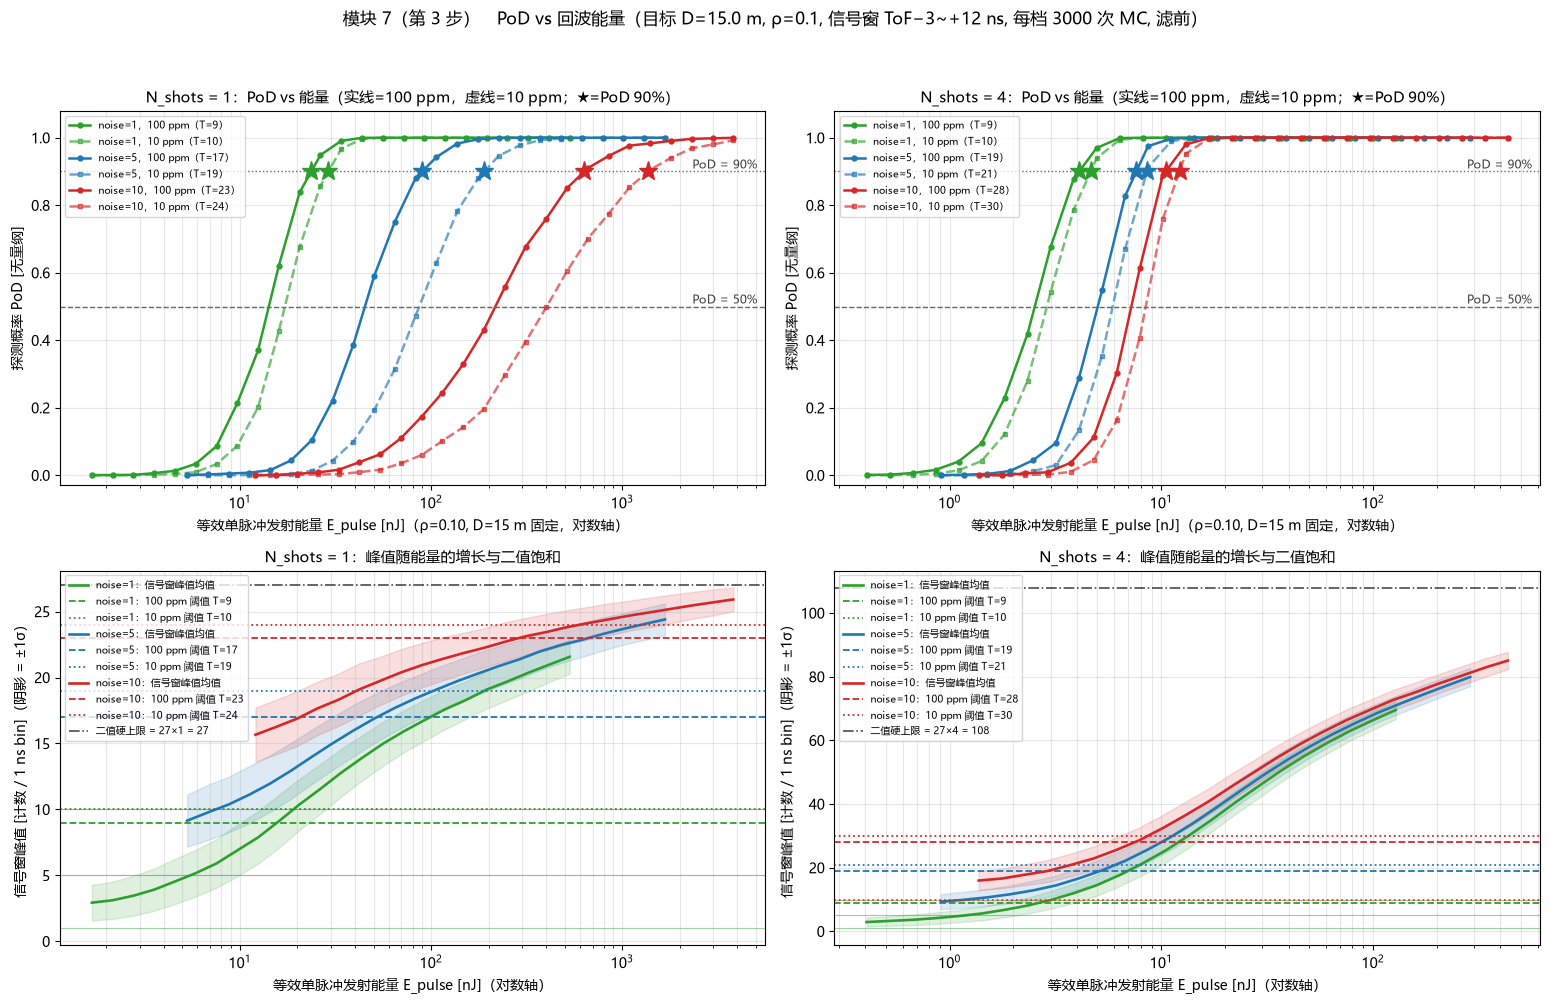

In [14]:
# ---- PoD 曲线图 ----
fig, axes = plt.subplots(2, len(N_SHOTS_LIST), figsize=(7.8*len(N_SHOTS_LIST), 10.2))
if len(N_SHOTS_LIST) == 1:
    axes = axes.reshape(2, 1)
_pcn = {1.0: "tab:green", 5.0: "tab:blue", 10.0: "tab:red", 2.0: "tab:orange",
        15.0: "tab:purple", 20.0: "tab:brown", 0.5: "tab:cyan"}

for j, n_shots in enumerate(N_SHOTS_LIST):
    aT, aB = axes[0, j], axes[1, j]
    for nt in NOISE_POD:
        key = (n_shots, nt)
        if key not in POD_RES:
            continue
        r = POD_RES[key]
        E_nJ = r["boost"] * E_PULSE_BASE * 1e9
        c = _pcn.get(nt, "k")
        for tag, ls, mk in [(_t100, "-", "o"), (_t10, "--", "s")]:
            T = r["T_map"][tag]
            aT.semilogx(E_nJ, r["pod"][str(T)], ls, marker=mk, color=c, lw=1.8, ms=3.5,
                        alpha=1.0 if ls == "-" else 0.65,
                        label=f"noise={nt:g}，{tag} ppm（T={T}）")
            b = r["b90"][tag]
            if np.isfinite(b):
                aT.plot([b*E_PULSE_BASE*1e9], [0.90], "*", color=c, ms=14, zorder=6)
        aB.semilogx(E_nJ, r["pmean"], "-", color=c, lw=1.9,
                    label=f"noise={nt:g}：信号窗峰值均值")
        aB.fill_between(E_nJ, r["pmean"]-r["pstd"], r["pmean"]+r["pstd"], color=c, alpha=0.15)
        for tag, ls in [(_t100, "--"), (_t10, ":")]:
            aB.axhline(r["T_map"][tag], color=c, ls=ls, lw=1.3,
                       label=f"noise={nt:g}：{tag} ppm 阈值 T={r['T_map'][tag]}")
        aB.axhline(r["noise"], color=c, ls="-", lw=0.8, alpha=0.45)
    aT.axhline(0.50, color="0.4", ls="--", lw=1.0)
    aT.axhline(0.90, color="0.4", ls=":", lw=1.0)
    aT.text(0.995, 0.50, "PoD = 50% ", fontsize=8.5, color="0.25", ha="right",
            va="bottom", transform=aT.get_yaxis_transform())
    aT.text(0.995, 0.90, "PoD = 90% ", fontsize=8.5, color="0.25", ha="right",
            va="bottom", transform=aT.get_yaxis_transform())
    aT.set_ylim(-0.03, 1.08)
    aT.set_xlabel("等效单脉冲发射能量 E_pulse [nJ]（ρ=0.10, D=15 m 固定，对数轴）")
    aT.set_ylabel("探测概率 PoD [无量纲]")
    aT.set_title(f"N_shots = {n_shots}：PoD vs 能量（实线=100 ppm，虚线=10 ppm；★=PoD 90%）",
                 fontsize=10.5)
    aT.legend(fontsize=7.5, loc="upper left"); aT.grid(alpha=0.3, which="both")

    aB.axhline(N_PIX_MACRO*n_shots, color="k", ls="-.", lw=1.2, alpha=0.7,
               label=f"二值硬上限 = 27×{n_shots} = {N_PIX_MACRO*n_shots}")
    aB.set_xlabel("等效单脉冲发射能量 E_pulse [nJ]（对数轴）")
    aB.set_ylabel("信号窗峰值 [计数 / 1 ns bin]（阴影 = ±1σ）")
    aB.set_title(f"N_shots = {n_shots}：峰值随能量的增长与二值饱和", fontsize=10.5)
    aB.legend(fontsize=7, loc="upper left"); aB.grid(alpha=0.3, which="both")

plt.suptitle(f"模块 7（第 3 步）　PoD vs 回波能量（目标 D={D_TARGET} m, ρ={RHO_TARGET}, "
             f"信号窗 ToF−{SIG_PRE_NS:.0f}~+{SIG_POST_NS:.0f} ns, 每档 {N_MC_POD} 次 MC, 滤前）",
             fontsize=12.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("pod_v02_pod_curves.png", dpi=110, bbox_inches="tight")
plt.show()


## 模块 8 — 汇总：不同环境噪声下的阈值与 PoD 50% / 90% 能量

三种等价的「能量」度量（在固定 ρ = 0.10、D = 15 m 下）：

| 度量 | 含义 |
|---|---|
| `E_pulse` [nJ] | 等效单脉冲发射能量 = 799 nJ × boost |
| `ρ_eff` | 等效目标反射率 = 0.10 × boost |
| `N_ph` | 宏像元单 shot 入射的信号光子数 = boost × Σf_pix × ∫r_sig,unit dt |

另给出**等效最远探测距离**：把 PoD 所需的回波强度换算成「若发射能量与反射率都不变，
该强度对应多远的目标」，由

$$\frac{\mathrm{link}(D)}{\mathrm{link}(D_\mathrm{ref})}
=\left(\frac{D_\mathrm{ref}}{D}\right)^{2}e^{-2\alpha (D-D_\mathrm{ref})}=\mathrm{boost}$$

反解 $D$（$D_\mathrm{ref}=15$ m）。**boost 越小 ⇒ 允许的距离越远**。


【PoD_esti v02 汇总】目标 D=15.0 m, ρ=0.1, 宏像元 9×3=27 SPAD, 统计窗 152 bin
基准（boost=1）：E_pulse=799.4 nJ, ρ=0.10, 宏像元单 shot 信号光子数 N_ph=2165.6
------------------------------------------------------------------------------------------------------------------------------------
N_shots  noise  ≈klux     噪点率    T   上限   PoD      boost E_pulse[nJ]     ρ_eff     N_ph     等效距离[m]
------------------------------------------------------------------------------------------------------------------------------------
      1   1.00     78  100ppm    9   27   50% 1.7722e-02       14.17   0.00177     38.4       111.6
      1   1.00     78  100ppm    9   27   90% 2.9551e-02       23.62   0.00296       64        86.6
      1   1.00     78   10ppm   10   27   50% 2.1508e-02       17.19   0.00215     46.6       101.4
      1   1.00     78   10ppm   10   27   90% 3.6363e-02       29.07   0.00364     78.7        78.2
      1   5.00    437  100ppm   17   27   50% 5.6407e-02       45.09   0.00564      122        62.9
  

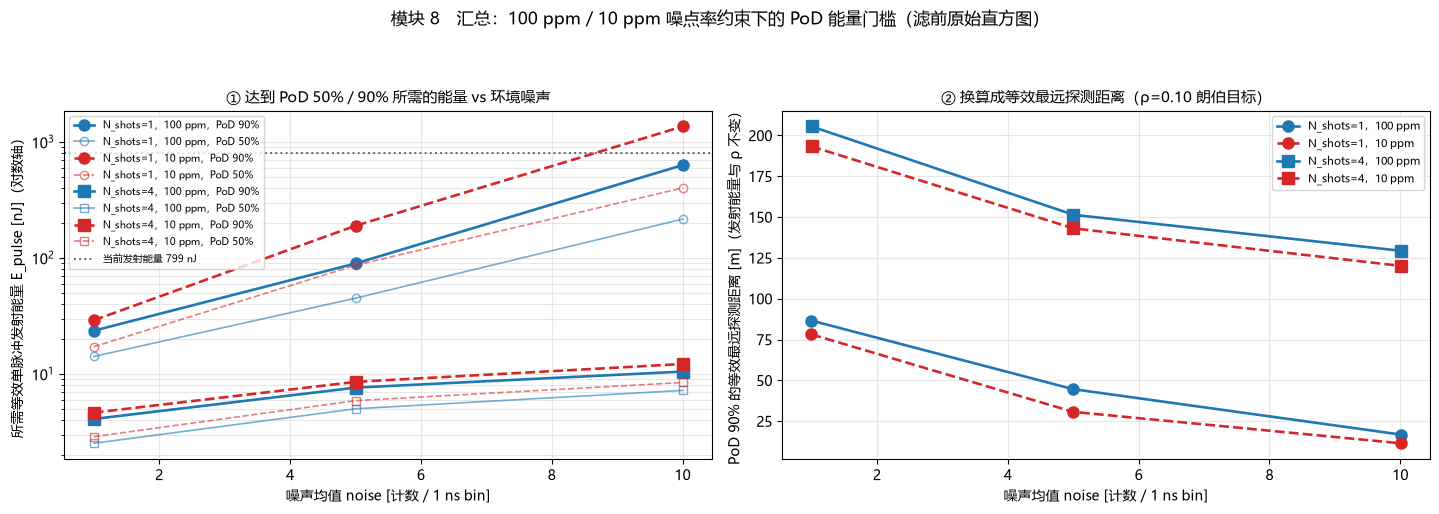

In [15]:
_NPH_BASE = np.trapezoid(R_SIG_UNIT_GEN, TF_GEN) * F_VALS.sum()

def equiv_distance(boost, D_ref=D_TARGET, p=PARAMS):
    """把能量倍数 boost 折成等效最远探测距离（boost 越小 ⇒ 距离越远）。"""
    if not np.isfinite(boost) or boost <= 0:
        return np.nan
    alpha = p["channel"]["alpha"]
    Ds = np.logspace(np.log10(0.3), np.log10(5000.0), 6000)
    vals = (D_ref**2 / Ds**2) * np.exp(-2*alpha*(Ds - D_ref))     # 随 D 单调下降
    if boost > vals[0] or boost < vals[-1]:
        return np.nan
    return float(np.interp(-boost, -vals, Ds))

print("="*132)
print(f"【PoD_esti v02 汇总】目标 D={D_TARGET} m, ρ={RHO_TARGET}, 宏像元 {MACRO_BX}×{MACRO_BY}"
      f"={N_PIX_MACRO} SPAD, 统计窗 {N_STAT} bin")
print(f"基准（boost=1）：E_pulse={E_PULSE_BASE*1e9:.1f} nJ, ρ=0.10, "
      f"宏像元单 shot 信号光子数 N_ph={_NPH_BASE:.1f}")
print("-"*132)
print(f"{'N_shots':>7}{'noise':>7}{'≈klux':>7}{'噪点率':>8}{'T':>5}{'上限':>5}{'PoD':>6}"
      f"{'boost':>11}{'E_pulse[nJ]':>12}{'ρ_eff':>10}{'N_ph':>9}{'等效距离[m]':>12}")
print("-"*132)
for n_shots in N_SHOTS_LIST:
    for nt in NOISE_POD:
        key = (n_shots, nt)
        if key not in POD_RES:
            continue
        r = POD_RES[key]
        klux = r["e_lambda"]/0.68*100
        for tag in [_t100, _t10]:
            T = r["T_map"][tag]
            for lv, b in [("50%", r["b50"][tag]), ("90%", r["b90"][tag])]:
                if not np.isfinite(b):
                    print(f"{n_shots:>7d}{r['noise']:>7.2f}{klux:>7.0f}{tag+'ppm':>8}"
                          f"{T:>5d}{r['n_tr']:>5d}{lv:>6}{'未达到':>11}")
                    continue
                print(f"{n_shots:>7d}{r['noise']:>7.2f}{klux:>7.0f}{tag+'ppm':>8}"
                      f"{T:>5d}{r['n_tr']:>5d}{lv:>6}{b:>11.4e}"
                      f"{b*E_PULSE_BASE*1e9:>12.4g}{RHO_TARGET*b:>10.3g}"
                      f"{_NPH_BASE*b:>9.3g}{equiv_distance(b):>12.1f}")
print("-"*132)
print("说明：")
print("  · boost 是对【回波光子率】的线性倍数；在 ρ、D 固定时等价于把发射能量乘同样倍数。")
print("  · ρ_eff > 1 只表示需要靠更高发射能量/更大口径/更近距离等其他途径达到同等回波，并非不物理。")
print("  · 等效距离 = 发射能量与反射率都不变时，该回波强度对应多远的目标（按 1/D²·exp(-2αD) 反解）。")

# ---- 汇总图 ----
fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
for n_shots, mk in zip(N_SHOTS_LIST, ["o", "s"]):
    for tag, ls, cc in [(_t100, "-", "tab:blue"), (_t10, "--", "tab:red")]:
        xs, y50, y90 = [], [], []
        for nt in NOISE_POD:
            key = (n_shots, nt)
            if key not in POD_RES:
                continue
            r = POD_RES[key]
            xs.append(r["noise"])
            y50.append(r["b50"][tag]*E_PULSE_BASE*1e9)
            y90.append(r["b90"][tag]*E_PULSE_BASE*1e9)
        if not xs:
            continue
        ax[0].plot(xs, y90, mk+ls, color=cc, lw=1.9, ms=8,
                   label=f"N_shots={n_shots}，{tag} ppm，PoD 90%")
        ax[0].plot(xs, y50, mk+ls, color=cc, lw=1.2, ms=6, mfc="none", alpha=0.6,
                   label=f"N_shots={n_shots}，{tag} ppm，PoD 50%")
ax[0].axhline(E_PULSE_BASE*1e9, color="0.4", ls=":", lw=1.4,
              label=f"当前发射能量 {E_PULSE_BASE*1e9:.0f} nJ")
ax[0].set_yscale("log")
ax[0].set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
ax[0].set_ylabel("所需等效单脉冲发射能量 E_pulse [nJ]（对数轴）")
ax[0].set_title("① 达到 PoD 50% / 90% 所需的能量 vs 环境噪声", fontsize=11)
ax[0].legend(fontsize=7.5); ax[0].grid(alpha=0.3, which="both")

for n_shots, mk in zip(N_SHOTS_LIST, ["o", "s"]):
    for tag, ls, cc in [(_t100, "-", "tab:blue"), (_t10, "--", "tab:red")]:
        xs, d90 = [], []
        for nt in NOISE_POD:
            key = (n_shots, nt)
            if key not in POD_RES:
                continue
            r = POD_RES[key]
            xs.append(r["noise"]); d90.append(equiv_distance(r["b90"][tag]))
        if not xs:
            continue
        ax[1].plot(xs, d90, mk+ls, color=cc, lw=1.9, ms=8,
                   label=f"N_shots={n_shots}，{tag} ppm")
ax[1].set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
ax[1].set_ylabel("PoD 90% 的等效最远探测距离 [m]（发射能量与 ρ 不变）")
ax[1].set_title("② 换算成等效最远探测距离（ρ=0.10 朗伯目标）", fontsize=11)
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.suptitle(f"模块 8　汇总：100 ppm / 10 ppm 噪点率约束下的 PoD 能量门槛（滤前原始直方图）",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("pod_v02_summary.png", dpi=110, bbox_inches="tight")
plt.show()
